# Aged Mouse Analysis

### Dependencies 



### Datasets 
#### Takasugi et al., Nature 2024 

# Directories, Dependencies, Helper Functions, & Data Pre-processing

In [240]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy as sp
import re
from collections import Counter
from copy import deepcopy
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MaxNLocator
import os
import ast
from scipy.odr import Model, RealData, ODR
from scipy.stats import (
    gaussian_kde,
    ttest_ind,
    fisher_exact,
    kruskal,
    mannwhitneyu
)
from matplotlib import gridspec
from matplotlib_venn import venn3
import zipfile
from glob import glob
import gzip
import tarfile
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, FixedLocator
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.patches as mpatches
from itertools import combinations
import pingouin as pg

from scipy import stats
from scipy.stats import spearmanr, wilcoxon, friedmanchisquare, ttest_1samp, ranksums
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from matplotlib.colors import LinearSegmentedColormap

print("packages have been successfully read in!")

packages have been successfully read in!


In [241]:
## Setting directories and reading in data 
# Reflect output from AAS pipeline (proj_dir), output folder (aa_subs_dir), and sample map for each sample 
# For reproducing analysis of the following datasets, it is highly recommended to maintain the same project directory structure... 

print("loading directories...")
CODE_DIR        = '/Users/alexmaropakis/Projects/BrainDecode/'
PROJ_DIR     = '/Users/alexmaropakis/Projects/Project_BrainDecode/'
INDIR           = PROJ_DIR + 'Analysis_Inputs/Takasugi_2024/'
OUTDIR          = CODE_DIR + 'Dependencies/Analysis_Outputs/Takasugi_2024/'
DEPDIR          = CODE_DIR + 'Dependencies/Takasugi_2024/'
MQ_DIR          = PROJ_DIR + 'mq_output/Takasugi_2024/'
PLOT_DIR        = PROJ_DIR + 'Plots/Takasugi_2024/'
SAMPLE_MAPS_DIR = CODE_DIR + 'Dependencies/Sample_maps/'

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

## Define dataset/TMT set folders 
#S1 AORTA
aorta_proj_dir      = OUTDIR + 'Aorta/'
aorta_aa_subs_dir   = INDIR + 'Aorta/'
aorta_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_aorta.xlsx')
aorta_samples       = ['S'+str(i) for i in list(set(aorta_sample_map['TMT plex']))]
aorta_mq            = MQ_DIR + 'Aorta/'

#S2 BRAIN 
brain_proj_dir      = OUTDIR + 'Brain/'
brain_aa_subs_dir   = INDIR + 'Brain/'
brain_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_brain.xlsx')
brain_samples       = ['S'+str(i) for i in list(set(brain_sample_map['TMT plex']))]
brain_mq            = MQ_DIR + 'Brain/'

#S3 HEART
heart_proj_dir      = OUTDIR + 'Heart/'
heart_aa_subs_dir   = INDIR + 'Heart/'
heart_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_heart.xlsx')
heart_samples       = ['S'+str(i) for i in list(set(heart_sample_map['TMT plex']))]
heart_mq            = MQ_DIR + 'Heart/'

#S4 KIDNEY
kidney_proj_dir      = OUTDIR + 'Kidney/'
kidney_aa_subs_dir   = INDIR + 'Kidney/'
kidney_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_kidney.xlsx')
kidney_samples       = ['S'+str(i) for i in list(set(kidney_sample_map['TMT plex']))]
kidney_mq            = MQ_DIR + 'Kidney/'

#S5 LIVER
liver_proj_dir      = OUTDIR + 'Liver/'
liver_aa_subs_dir   = INDIR + 'Liver/'
liver_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_liver.xlsx')
liver_samples       = ['S'+str(i) for i in list(set(liver_sample_map['TMT plex']))]
liver_mq            = MQ_DIR + 'Liver/'

#S6 LUNG
lung_proj_dir      = OUTDIR + 'Lung/'
lung_aa_subs_dir   = INDIR + 'Lung/'
lung_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_lung.xlsx')
lung_samples       = ['S'+str(i) for i in list(set(lung_sample_map['TMT plex']))]
lung_mq            = MQ_DIR + 'Lung/'

#S7 MUSCLE
muscle_proj_dir      = OUTDIR + 'Muscle/'
muscle_aa_subs_dir   = INDIR + 'Muscle/'
muscle_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_muscle.xlsx')
muscle_samples       = ['S'+str(i) for i in list(set(muscle_sample_map['TMT plex']))]
muscle_mq            = MQ_DIR + 'Muscle/'

#S8 SKIN
skin_proj_dir      = OUTDIR + 'Skin/'
skin_aa_subs_dir   = INDIR + 'Skin/'
skin_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_skin.xlsx')
skin_samples       = ['S'+str(i) for i in list(set(skin_sample_map['TMT plex']))]
skin_mq            = MQ_DIR + 'Skin/'

#lists to quickly index dataset-specific sample maps from just the dataset name
datasets = ['Aorta', 'Brain', 'Heart', 'Kidney', 'Liver', 'Lung', 'Muscle', 'Skin']
data_dir_list = [aorta_aa_subs_dir, brain_aa_subs_dir, heart_aa_subs_dir, kidney_aa_subs_dir, liver_aa_subs_dir, lung_aa_subs_dir, muscle_aa_subs_dir, skin_aa_subs_dir]
samples_list = [aorta_samples, brain_samples, heart_samples, kidney_samples, liver_samples, lung_samples, muscle_samples, skin_samples]
sample_map_list = [aorta_sample_map, brain_sample_map, heart_sample_map, kidney_sample_map, liver_sample_map, lung_sample_map, muscle_sample_map, skin_sample_map]
proj_dir_list = [aorta_proj_dir, brain_proj_dir, heart_proj_dir, kidney_proj_dir, liver_proj_dir, lung_proj_dir, muscle_proj_dir, skin_proj_dir]
mq_dir_list = [aorta_mq, brain_mq, heart_mq, kidney_mq, liver_mq, lung_mq, muscle_mq, skin_mq]


print("directories loaded successfully!")

loading directories...
directories loaded successfully!


In [242]:
# Read in data generated from dependencies code
# if dependencies have not been generated, go back and generate in Analysis_Dependencies_ipynb

pos_prob_df = pd.read_csv(DEPDIR+'Position_probability_fragment_ion_data.csv', index_col=0)
print(pos_prob_df)
frag_dict = pickle.load(open(DEPDIR+'Fragment_ion_dict.p', 'rb')) ### keys of frag_dict refer to the index in pos_prob_df
print(frag_dict)

SAAP_quant_df = pd.read_excel(DEPDIR+'SAAP_precursor_reporter_quant.xlsx', index_col=0)
#SAAP_precursor_reporter_quant_data.xlsx contains both precursor and reporter ion data for validated SAAPs
print(SAAP_quant_df)
SAAP_quant_df_list = [SAAP_quant_df.loc[SAAP_quant_df['Dataset']==ds] for ds in datasets]

                              SAAP                             BP       AAS  \
0                        SALSGLLHR                      AALSGLLHR    A to S   
1                        SALSGLLHR                      AALSGLLHR    A to S   
2                         PATVSLPR                       VATVSLPR    V to P   
3                         PFLENVIR                       VFLENVIR    V to P   
4                        LPGGTTPGK                      LVGGTTPGK    V to P   
..                             ...                            ...       ...   
122               STLSVITSGVQWIQDR               STLSVIPSGVQWIQDR    P to T   
123  ETTWHGQGQDQGQGPSQESAAEQGAVEKQ  ETPWHGQGQDQGQGPSQESAAEQGAVEKQ    P to T   
124        DNLTLWNSDTQGDEAEAGEGGEN        DNLTLWTSDTQGDEAEAGEGGEN    T to N   
125            DSTYSMSSLLTLTKDEYER            DSTYSMSSTLTLTKDEYER  T to I/L   
126            LYTWGVVEVENPEHNDFLK            LYPWGVVEVENPEHNDFLK    P to T   

     AAS index  Positional probability  charge TMT 

## Data Pre-processing

### a. Assess data completeness

In [243]:
# Assess data completeness of SAAPs in SAAP_quant_df 
print(f'{len(SAAP_quant_df):,} total SAAP observations in original dataset')
SAAP_quant_complete_df=SAAP_quant_df.dropna()
print(f'{len(SAAP_quant_complete_df):,} fully complete SAAP observations retained')
print(f'{100*(len(SAAP_quant_complete_df)/len(SAAP_quant_df)):.2f}% original dataset completeness')

# Option to replace read-in SAAP_quant_df with SAAP_quant_df that has 100% data completeness
# SAAP_quant_df = SAAP_quant_complete_df 

19,520 total SAAP observations in original dataset
17,877 fully complete SAAP observations retained
91.58% original dataset completeness


  Dataset  Completeness
0   Aorta     97.688752
1   Brain     97.178683
2   Heart     99.084808
3  Kidney     96.280992
4   Liver     94.318182
5    Lung     97.914269
6  Muscle     98.430024
7    Skin     98.441558


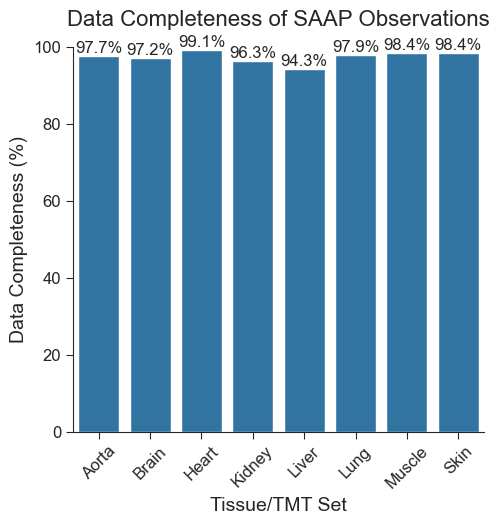

In [292]:
# Plot data completeness per tissue/TMT set 
comp_cols=['Positional_probability','SAAP_PEP','BP_PEP','MTP_PrecInt','BP_PrecInt','Prec_RAAS','MTP_ReportInt','BP_ReportInt','Reporter_RAAS','BP_ReportInt_Norm','MTP_ReportInt_Norm']

comp_df = SAAP_quant_df.copy()
plot_rows=[]
for ds in sorted(comp_df['Dataset'].dropna().unique()):
    ds_df = comp_df[comp_df['Dataset']==ds]
    total_val = len(ds_df)*len(comp_cols)
    nonmissing_val = sum(ds_df[c].notna().sum() for c in comp_cols)
    completeness = 100*(nonmissing_val/total_val)
    plot_rows.append({'Dataset': ds, 'Completeness': completeness})

plot_df = pd.DataFrame(plot_rows,columns=['Dataset','Completeness'])
print(plot_df)

fig,ax = plt.subplots(figsize=(5.3,5))
sns.set_style('ticks')
sns.barplot(data=plot_df,x='Dataset',y='Completeness',color=colors[0],ax=ax)
ax.tick_params('both',labelsize=12,length=5)
ax.tick_params(axis='x',rotation=45)
plt.xlabel('Tissue/TMT Set',fontsize=14)
plt.ylabel('Data Completeness (%)',fontsize=14)
plt.ylim(0,100) 
plt.title('Data Completeness of SAAP Observations',fontsize=16,pad=15)
sns.despine()

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%',label_type='edge',fontsize=12)

plt.savefig(PLOT_DIR + 'SAAP_data_completeness.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR + 'SAAP_data_completeness.png',dpi=600,bbox_inches='tight')

### b. Remove immunoglobulins and trypsin mapping SAAPs 

In [245]:
# Assign each SAAP a source protein/gene from evidence.txt & drop Ig/trypsin

"""
Each SAAP (MTP_seq) is a substituted peptide that exists only in the synthetic search
space, so its parent protein is read off the BASE peptide (BP_seq) — the reference
sequence string-searched across every dataset's MaxQuant evidence.txt. Gene symbols and
protein descriptions come from the proteinGroups.txt FASTA headers (GN= field). SAAPs
whose base peptide maps to an immunoglobulin chain or to trypsin are dropped as
contaminants before any downstream QC.
"""

# accession -> (gene, description) parsed from every dataset's FASTA headers
hdr_re = re.compile(r'(?:sp|tr)\|([^|]+)\|\S+\s+(.+?)\s+OS=')
gn_re  = re.compile(r'GN=(\S+)')
acc_gene, acc_desc = {}, {}
for mq_dir in mq_dir_list:
    headers = pd.read_csv(mq_dir+'proteinGroups.txt', sep='\t', usecols=['Fasta headers'])['Fasta headers']
    for header in headers.dropna():
        for entry in header.split(';'):
            m = hdr_re.search(entry)
            if not m:
                continue
            acc_desc.setdefault(m.group(1), m.group(2).strip())
            g = gn_re.search(entry)
            if g:
                acc_gene.setdefault(m.group(1), g.group(1))
print(f'{len(acc_desc):,} reference proteins parsed from FASTA headers')

# peptide sequence -> MaxQuant 'Proteins' string, string-searched across every evidence.txt
seq_to_proteins = {}
for mq_dir in mq_dir_list:
    ev = pd.read_csv(mq_dir+'evidence.txt', sep='\t', usecols=['Sequence', 'Proteins'])
    for seq, prot in zip(ev['Sequence'], ev['Proteins'].astype(str)):
        if prot != 'nan':
            seq_to_proteins.setdefault(seq, prot)
print(f'{len(seq_to_proteins):,} unique peptide sequences indexed across {len(mq_dir_list)} evidence.txt files')

def proteins_to_accessions(protein_str):
    """Real UniProt accessions in a MaxQuant 'Proteins' string (drops synthetic MTP| entries)."""
    accs = []
    for tok in str(protein_str).split(';'):
        tok = tok.replace('CON__', '')
        if tok.startswith('MTP'):
            continue
        m = re.match(r'(?:sp|tr)\|([^|]+)\|', tok) or re.match(r'^([A-Z0-9][A-Z0-9-]+)$', tok)
        if m:
            accs.append(m.group(1).split('-')[0])
    return list(dict.fromkeys(accs))  # unique, order-preserving

# resolve each SAAP's base peptide to accessions / genes / descriptions
row_accs = [proteins_to_accessions(seq_to_proteins.get(bp, '')) for bp in SAAP_quant_df['BP_seq']]
row_genes = [[acc_gene.get(a, '') for a in accs] for accs in row_accs]
row_descs = [[acc_desc.get(a, '') for a in accs] for accs in row_accs]

def first_nonempty(values):
    return next((v for v in values if v), '')

SAAP_quant_df['Source_accessions'] = [';'.join(accs) for accs in row_accs]
SAAP_quant_df['Source_gene']       = [first_nonempty(g) for g in row_genes]
SAAP_quant_df['Source_protein']    = [first_nonempty(d) for d in row_descs]
print(SAAP_quant_df[['MTP_seq', 'BP_seq', 'Source_gene', 'Source_protein']].head(10).to_string())

# flag immunoglobulin (antibody chains) and trypsin (digestion contaminant) source proteins.
# Matching is gene- and accession-based to avoid false positives such as Ig-superfamily
# members, IgLON, anti-trypsin, or chymotrypsin.
ig_gene_re   = re.compile(r'(?i)^Ig[hkl][vjdcmage0-9]')
ig_desc_re   = re.compile(r'(?i)^(immunoglobulin|ig)[ -](heavy|kappa|lambda|gamma|mu|alpha|delta|epsilon|j)')
tryp_desc_re = re.compile(r'(?i)\btrypsin')
tryp_skip_re = re.compile(r'(?i)(anti-?trypsin|trypsin inhibitor|chymotrypsin)')
TRYPSIN_ACCESSIONS = {'P00761', 'P00760'}  # Sus scrofa / Bos taurus digestion trypsin contaminants

def is_immunoglobulin(accs):
    return any(ig_gene_re.match(acc_gene.get(a, '')) or acc_gene.get(a, '').lower() == 'jchain'
               or ig_desc_re.match(acc_desc.get(a, '')) for a in accs)

def is_trypsin(accs):
    return any(a in TRYPSIN_ACCESSIONS or
               (tryp_desc_re.search(acc_desc.get(a, '')) and not tryp_skip_re.search(acc_desc.get(a, '')))
               for a in accs)

SAAP_quant_df['immunoglobulin'] = ['YES' if is_immunoglobulin(accs) else 'NO' for accs in row_accs]
SAAP_quant_df['trypsin']        = ['YES' if is_trypsin(accs) else 'NO' for accs in row_accs]
print(f"\n{(SAAP_quant_df['immunoglobulin'] == 'YES').sum():,} SAAP observations match immunoglobulins")
print(f"{(SAAP_quant_df['trypsin'] == 'YES').sum():,} SAAP observations match trypsin")
print('immunoglobulin source proteins removed:',
      sorted(SAAP_quant_df.loc[SAAP_quant_df['immunoglobulin'] == 'YES', 'Source_protein'].unique()))
print('trypsin source proteins removed:',
      sorted(SAAP_quant_df.loc[SAAP_quant_df['trypsin'] == 'YES', 'Source_accessions'].unique()))

11,818 reference proteins parsed from FASTA headers
124,861 unique peptide sequences indexed across 8 evidence.txt files
              MTP_seq     BP_seq Source_gene                                    Source_protein
Row Number                                                                                    
0           SALSGLLHR  AALSGLLHR       Hadhb  Trifunctional enzyme subunit beta, mitochondrial
1           SALSGLLHR  AALSGLLHR       Hadhb  Trifunctional enzyme subunit beta, mitochondrial
2           SALSGLLHR  AALSGLLHR       Hadhb  Trifunctional enzyme subunit beta, mitochondrial
3           SALSGLLHR  AALSGLLHR       Hadhb  Trifunctional enzyme subunit beta, mitochondrial
4           SALSGLLHR  AALSGLLHR       Hadhb  Trifunctional enzyme subunit beta, mitochondrial
5           SALSGLLHR  AALSGLLHR       Hadhb  Trifunctional enzyme subunit beta, mitochondrial
6           SALSGLLHR  AALSGLLHR       Hadhb  Trifunctional enzyme subunit beta, mitochondrial
7           SALSGLLHR  A

4
1
403
          Category  Count
0  Immunoglobulins      4
1         Trypsins      1
2            SAAPs    403


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_7154/496556860.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_df, x='Category', y='Count',palette='colorblind',alpha=1)


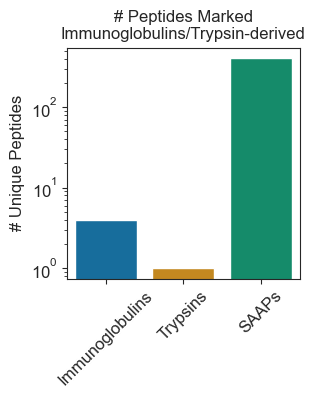

In [246]:
# Plot the number of trypsin/immunoglobulin-matching peptides 
n_immunoglobulin = SAAP_quant_df.loc[SAAP_quant_df['immunoglobulin'] == 'YES', 'Source_protein'].nunique()
print(n_immunoglobulin)

n_trypsin = SAAP_quant_df.loc[SAAP_quant_df['trypsin'] == 'YES', 'Source_protein'].nunique()
print(n_trypsin)

n_main_SAAP = SAAP_quant_df.loc[(SAAP_quant_df['trypsin'] == 'NO') & (SAAP_quant_df['immunoglobulin'] == 'NO'), 'Source_protein'].nunique()
print(n_main_SAAP)

plot_df = pd.DataFrame({'Category': ['Immunoglobulins', 'Trypsins', 'SAAPs'],'Count': [n_immunoglobulin, n_trypsin, n_main_SAAP]})
print(plot_df)

plt.figure(figsize=(3,3))
sns.set_style(style='ticks')
ax = sns.barplot(data=plot_df, x='Category', y='Count',palette='colorblind',alpha=1)
ax.set_yscale('log')
ax.set_xlabel('')
ax.set_ylabel('# Unique Peptides',fontsize=12)
ax.set_title('# Peptides Marked\nImmunoglobulins/Trypsin-derived',fontsize=12)
ax.tick_params(axis='x',rotation=45,labelsize=12)
ax.tick_params(axis='y',labelsize=12)

plt.savefig(PLOT_DIR+'Igg_trypsin_filtering_barplot.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Igg_trypsin_filtering_barplot.png',dpi=600,bbox_inches='tight')

In [247]:
# drop the contaminant SAAPs and rebuild the per-dataset views
n_before = len(SAAP_quant_df)
SAAP_quant_df = SAAP_quant_df.loc[(SAAP_quant_df['immunoglobulin'] == 'NO') &
                                  (SAAP_quant_df['trypsin'] == 'NO')].copy()
print(f'\n{n_before:,} -> {len(SAAP_quant_df):,} SAAP observations after removing immunoglobulin/trypsin matches')
SAAP_quant_df_list = [SAAP_quant_df.loc[SAAP_quant_df['Dataset'] == ds] for ds in datasets]


19,520 -> 19,248 SAAP observations after removing immunoglobulin/trypsin matches


# 1. SAAP Detection & QC

## 1a Dataset Metrics

In [248]:
# function to get number of peptides in each filtration category 

def get_filter_df(data_dir, samples):
    """ 
    function that reads in output from decode pipeline to get number of peptides in each category
    Input: directory with output files for dataset, dataset samples/TMT set names
    output: dataframe with the number of peptides in each category
    """
    dp_ev_dict = pickle.load(open(data_dir+'DP_search_evidence_dict.p', 'rb'))
    dp_dict = pickle.load(open(data_dir+'DP_dict.p', 'rb'))
    mtp_dict = pickle.load(open(data_dir+'MTP_dict.p', 'rb'))
    ptm_dict = pickle.load(open(data_dir+'PTM_dict.p', 'rb'))
    hc_mtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb')) # dictionary of putative substitutions that pass FDR correction
    substr_dict = pickle.load(open(data_dir+'genome_substr_dict.p', 'rb'))
    val_mtp_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    
    rows = []
    for s in samples:
        seqs = [[x for y in list(mtp_dict[s]['mistranslated sequence'].values()) for x in y] for s in samples]
        seqs = [x for y in seqs for x in y]
        if 'all_6frame_seqs' in substr_dict.keys():
            homolog_seqs = substr_dict['all_6frame_seqs']
        else:
            homolog_seqs = substr_dict['all_frame6_seqs']
        seqs_hom = [x for x in seqs if x in homolog_seqs]
        
        n_main = len(dp_ev_dict[s]['Raw file'])
        n_dp = len(dp_dict[s]['Raw file'])
        n_ptm = len(ptm_dict[s]['Raw file'])
        n_aas = len(mtp_dict[s]['Raw file'])
        n_nohom = len([i for i,x in mtp_dict[s]['mistranslated sequence'].items() if all(y not in seqs_hom for y in x)])
        n_hc = len([i for i,x in hc_mtp_dict[s]['mistranslated sequence'].items() if all(y not in seqs_hom for y in x)])
        n_val = len(val_mtp_dict[s]['Raw file'])

        rows.append([s, n_main, n_dp, n_ptm, n_aas, n_nohom, n_hc, n_val])
    df = pd.DataFrame(rows, columns=['TMT set', 'Main peptides', 'DP', 'PTM', 'AAS', 'Non-homologous', 'High-confidence', 'Validated'])

    return(df)

<Figure size 600x500 with 0 Axes>

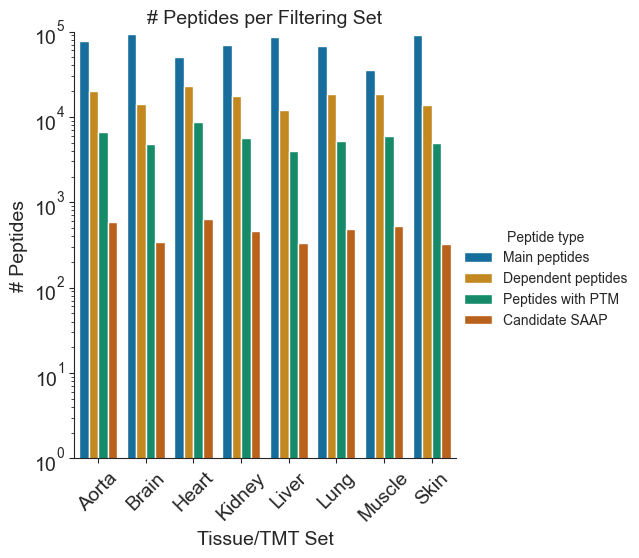

In [249]:
# N peptide IDs through filtering steps for QC figure 

# get number of samples in each dataset
n_samples_data = []
total = 0
for ds in datasets:
    sample_map = sample_map_list[datasets.index(ds)]
    samples = sample_map['sample_name'].values
    
    n_samples = len(samples)
    total += n_samples
    n_samples_data.append([ds, n_samples])

n_samples_df = pd.DataFrame(n_samples_data, columns=['Dataset','N samples'])
# print(n_samples_df)
n_samples_df.to_excel(OUTDIR+'N_samples_in_datasets.xlsx')

# create a dict containing dfs generated above per dataset 
filter_dict = {}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    filter_dict[ds] = get_filter_df(data_dir, samples)

for ds in datasets:
    filter_dict[ds]['Dataset'] = [ds]*len(filter_dict[ds])
pickle.dump(filter_dict, open(OUTDIR+'Modified_peptide_filter_dict_DP2valSAAP.p', 'wb'))
# filter_dict = pickle.load(open(OUTDIR+'Modified_peptide_filter_dict_DP2valSAAP.p', 'rb'))))

all_df = pd.concat([filter_dict[ds] for ds in datasets])

sum_dict = {}
for col in all_df.columns:
    if col not in ['TMT set','Dataset','Tissue']:
        sum_dict[col] = np.nansum(all_df[col].values)
# print(sum_dict)

# filtering modified peptides to candidate SAAP
barplot_rows = []
for i, row in all_df.iterrows():
    barplot_rows.append([row['Dataset'], row['Main peptides'], 'Main peptides', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['DP'], 'Dependent peptides', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['PTM'], 'Peptides with PTM', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['High-confidence'], 'Candidate SAAP', row['TMT set']])
barplot_df = pd.DataFrame(barplot_rows, columns=['Dataset', 'N peptide IDs', 'Peptide type', 'TMT set'])

# plotting 
plt.figure(figsize=(6,5))
sns.set_style(style='ticks')
ax = sns.catplot(data=barplot_df,kind='bar',
                 x='Dataset',y='N peptide IDs',
                 hue='Peptide type',palette='colorblind',
                 alpha=1)

ax.set(yscale='log', ylim=(1, 1e5))
ax.set_axis_labels('Tissue/TMT Set', '# Peptides',fontsize=14)
for ax in ax.axes.flat:
    ax.set_ylabel('# Peptides', fontsize=14)
    ax.tick_params(axis='x',rotation=45,labelsize=14)
    ax.tick_params(axis='y',labelsize=14)
    ax.set_title('# Peptides per Filtering Set',fontsize=14)

plt.savefig(PLOT_DIR+'Dataset_filtering_barplot.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Dataset_filtering_barplot.png',dpi=600,bbox_inches='tight')

In [250]:
# functions to get number of unique candidate substituted peptides and number of unique validated substituted peptides for each sample in each dataset
def get_n_unq_seqs(data_dir, s):
    """ input: dataset directory, sample
        output: number of unique candidate substituted peptides
    """
    hc_mtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb'))
    s_seqs = [x for y in hc_mtp_dict[s]['mistranslated sequence'].values() for x in y]
    s_seqs = list(set(s_seqs))
    n_seqs = len(s_seqs)
    return(n_seqs)

def get_n_unq_val(data_dir, s):
    """ input: dataset directory, sample
        output: number of unique validated substituted peptides
    """
    val_mtp_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p', 'rb'))
    s_seqs = list(val_mtp_dict[s]['mistranslated sequence'].values())
    s_seqs = list(set(s_seqs))
    n_seqs = len(s_seqs)
    return(n_seqs)

### Percentage of candidate SAAPs validated through database search

Aorta
Brain
Heart
Kidney
Liver
Lung
Muscle
Skin


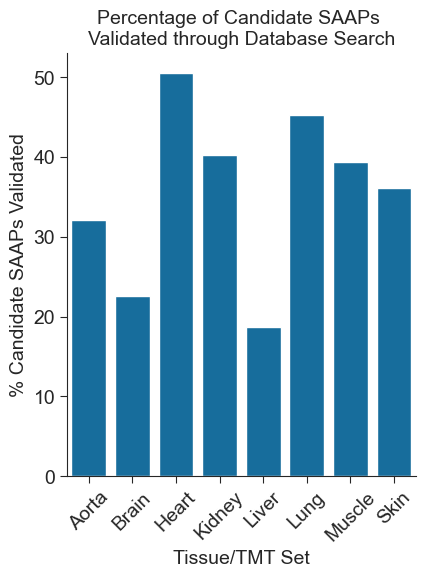

In [251]:
# Percentage of candidate SAAPs validated through database search 

# get dataframe with number of unique substituted peptides, candidate and validated
rows = []
cols = ['Dataset', 'N SAAP sequences', 'SAAP sequence type', 'TMT set']

for i,ds in enumerate(datasets):
    samples=samples_list[i]
    data_dir=data_dir_list[i]
    for s in samples:
        n_seqs = get_n_unq_seqs(data_dir,s)
        n_val_seqs = get_n_unq_val(data_dir,s)
        rows.append([ds,n_seqs,'Candidate',s])
        rows.append([ds,n_val_seqs,'Validated',s])
plt_df = pd.DataFrame(rows,columns=cols)

# get dataframe with percentage of peptides validated and percentage of peptides with no genome homology (from ds_filter_dict.p generated above)
pcnt_rows = []
for i,ds in enumerate(datasets):
    print(ds)
    data_dir = data_dir_list[i]
    samples = samples_list[i]
    ds_plt_df = plt_df.loc[plt_df['Dataset']==ds,:]
    ds_filter_dict = filter_dict[ds]
    for j,s in enumerate(samples):
        s_df = ds_plt_df.loc[ds_plt_df['TMT set']==s,:]
        n_cand = s_df.loc[s_df['SAAP sequence type']=='Candidate', 'N SAAP sequences'].values[0]
        n_val = s_df.loc[s_df['SAAP sequence type']=='Validated', 'N SAAP sequences'].values[0]
        val_pcnt = 100*(n_val/n_cand)
        n_aas = ds_filter_dict['AAS'][j]
        pcnt_rows.append([ds,s, val_pcnt, 'Validated SAAP'])
pcnt_df = pd.DataFrame(pcnt_rows, columns=['Dataset', 'TMT set', '% peptides', '% type'])
nonrectum_row = [i for i,row in pcnt_df.iterrows() if (row['TMT set']!='rectum') and (row['TMT set']!='bonemarrow')] # too little data, removed these tissues from analysis
pcnt_df = pcnt_df.loc[nonrectum_row]
pcnt_df.to_excel(DEPDIR+'percent_validated_genomehomol_SAAP.xlsx')
avg_pcnt_df = pcnt_df.groupby(['Dataset', 'TMT set', '% type'], as_index=False).agg({'% peptides': 'mean'})
# pcnt_df = pd.read_excel(DEPDIR+'percent_validated_genomehomol_SAAP.xlsx', index_col=0)

# plot percentage of candidate SAAPs validated across samples
sns.set_style(style='ticks')
fix,ax = plt.subplots(figsize=(4.5,5.5))
sns.barplot(data=avg_pcnt_df,x='Dataset',
            y='% peptides',hue='% type',
            palette='colorblind')
ax.get_legend().remove()
sns.despine()
plt.yticks(fontsize=14)
plt.xticks(rotation=45,fontsize=14)
plt.tick_params(axis='both',length=5)
plt.xlabel('Tissue/TMT Set',fontsize=14)
plt.title('Percentage of Candidate SAAPs \nValidated through Database Search',fontsize=14)
plt.ylabel('% Candidate SAAPs Validated',fontsize=14)

plt.savefig(PLOT_DIR+'Percent_validated_allDS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'Percent_validated_allDS.png',dpi=600,bbox_inches='tight')

## 1b Validation Metrics

### Positional probability filtering

8272
19248


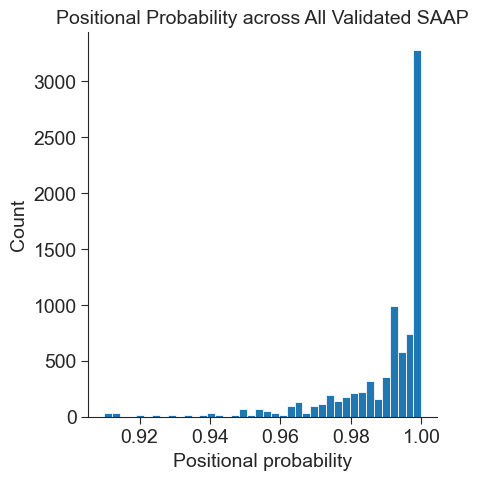

In [252]:
# Filter SAAP_quant_df by SAAP with positional probability => 0.9
SAAP_quant_df_posprobfilt = SAAP_quant_df[SAAP_quant_df['Positional_probability'] >= 0.9]
print(len(SAAP_quant_df_posprobfilt))
print(len(SAAP_quant_df))
SAAP_quant_df = SAAP_quant_df_posprobfilt

# Filtered distribution 
fig,ax=plt.subplots(figsize=(4.5,5))
sns.set_style(style='ticks')
loc_df=SAAP_quant_df['Positional_probability']
loc_df=(loc_df).replace([np.inf,-np.inf],np.nan).dropna()
sns.histplot(x=loc_df,bins=40,color=colors[0],alpha=1)
sns.despine()
ax.tick_params('both',labelsize=14)
plt.xlabel('Positional probability',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.tick_params(axis='both', length=5)
plt.title('Positional Probability across All Validated SAAP',fontsize=14)

plt.savefig(PLOT_DIR+'loc_prob_filt_AAS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'loc_prob_filt_AAS.png',dpi=600,bbox_inches='tight')

### PEP filtering

8272
8272


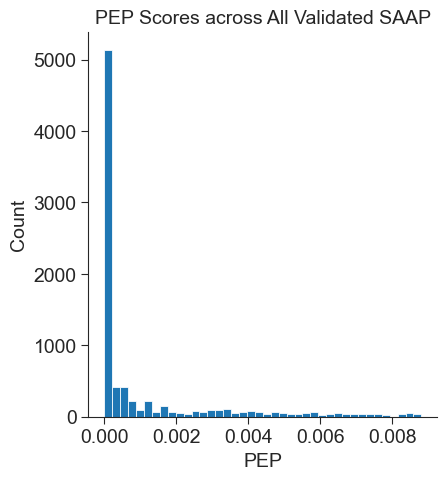

In [253]:
# Filter out SAAP with PEP <= 0.01 
SAAP_quant_df_PEPfilt = SAAP_quant_df[SAAP_quant_df['SAAP_PEP'] <= 0.1]
print(len(SAAP_quant_df_PEPfilt))
print(len(SAAP_quant_df))
SAAP_quant_df = SAAP_quant_df_PEPfilt

# Plot PEP distribution for all SAAP 
fig,ax=plt.subplots(figsize=(4.5,5))
sns.set_style(style='ticks')
pep_df=SAAP_quant_df['SAAP_PEP']
pep_df=(pep_df).replace([np.inf,-np.inf],np.nan).dropna()
sns.histplot(x=pep_df,bins=40,color=colors[0],alpha=1)
sns.despine()
ax.tick_params('both',labelsize=14)
plt.xlabel('PEP',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.tick_params(axis='both', length=5)
plt.title('PEP Scores across All Validated SAAP',fontsize=14)

plt.savefig(PLOT_DIR+'PEP_all_AAS.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'PEP_all_AAS.png',dpi=600,bbox_inches='tight')

### Fragment ion support at substitution site

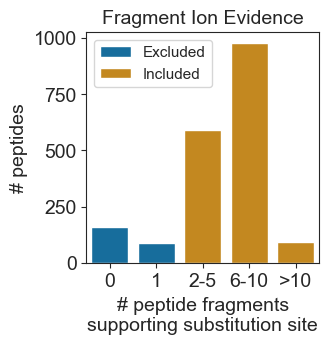

In [254]:
# Fragment ion support at substitution site 
fig,ax=plt.subplots(figsize=(3,3))
plot_df = pd.read_excel(DEPDIR+'fragments_per_saap_4barplot_allDS.xlsx', index_col=0)
sns.set_style('ticks')
sns.barplot(data=plot_df, x='Bin', y='Count', hue='Used', dodge=False, palette='colorblind')
ax.tick_params('both', labelsize=14)

plt.ylabel('# peptides', fontsize=14)
sns.set_style(style='ticks')
handles, labels = ax.get_legend_handles_labels()
plt.title(f'Fragment Ion Evidence',fontsize=14)
plt.legend(handles=handles, loc='upper left', labels=['Excluded', 'Included'], fontsize=11)
plt.xlabel('# peptide fragments\nsupporting substitution site', fontsize=14)

plt.savefig(PLOT_DIR + 'fragment_ion_evidence_barplot_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR + 'fragment_ion_evidence_barplot_allDS.png',dpi=600,bbox_inches='tight')

### PEP scores and q values

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_7154/1014909217.py:15: RuntimeWarning: divide by zero encountered in log10
  plot_df['-log q'] = plot_df.apply(lambda x: -np.log10(x['q-value']),axis=1)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_7154/1014909217.py:16: RuntimeWarning: divide by zero encountered in log10
  plot_df['-log PEP'] = plot_df.apply(lambda x: -np.log10(x['PEP']),axis=1)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_7154/1014909217.py:19: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.ecdfplot(plot_df, x='-log q', label='log$_{10}$(q)', palette='colorblind')
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_7154/1014909217.py:20: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.ecdfplot(plot_df, x='-log PEP', label='log$_{10}$(PEP)', palette='colorblind')


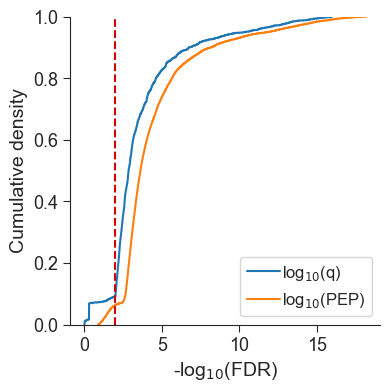

In [255]:
# cumulative density of q-values and PEPs across all datasets and samples
# plot the p-values determined by MaxQuant and the q-values determined from only the substituted peptides
plot_rows = []
plot_cols = ['Dataset', 'TMT/Tissue', 'q-value', 'PEP']
for ds in datasets:
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    qmtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb'))
    for s in samples:
        s_dict = qmtp_dict[s]
        for k,v in s_dict['Posterior subs probability'].items():
            plot_rows.append([ds, s, 1-v[0], s_dict['q-value'][k][0]])
plot_df = pd.DataFrame(plot_rows, columns=plot_cols)

plot_df['-log q'] = plot_df.apply(lambda x: -np.log10(x['q-value']),axis=1)
plot_df['-log PEP'] = plot_df.apply(lambda x: -np.log10(x['PEP']),axis=1)
fig,ax = plt.subplots(figsize=(4,4))
sns.set_style(style='ticks')
sns.ecdfplot(plot_df, x='-log q', label='log$_{10}$(q)', palette='colorblind')
sns.ecdfplot(plot_df, x='-log PEP', label='log$_{10}$(PEP)', palette='colorblind')
plt.ylabel('Cumulative density', fontsize=14)
plt.xlabel('-log$_{10}$(FDR)', fontsize=14)
ax.tick_params('both', labelsize=13)
sns.despine()
plt.plot((2, 2), plt.ylim(), '--', color="#d40000")
plt.tick_params(axis='both', length=5)
plt.legend(loc='lower right', fontsize=12, handletextpad=0.1)

plt.savefig(PLOT_DIR+'qvalue_CumDensity_plot.pdf', bbox_inches='tight')

<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:56: SyntaxWarning: invalid escape sequence '\g'
<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:56: SyntaxWarning: invalid escape sequence '\g'
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_7154/2400756835.py:35: SyntaxWarning: invalid escape sequence '\g'
  all_ds_plot_df['RAAS group'] = ['$\geq$0' if raas>=0 else '<0' for i,raas in list(enumerate(all_ds_plot_df['Precursor RAAS'].values))]
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_7154/2400756835.py:43: SyntaxWarning: invalid escape sequence '\g'
  sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='-log q', fill=False, palette='colorblind', label='log$_{10}$(RAAS)$\geq$0')
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_7154/2400756835.py:56: SyntaxWarning: invalid escape sequence '\g'
  sns.kdeplot(data = high_

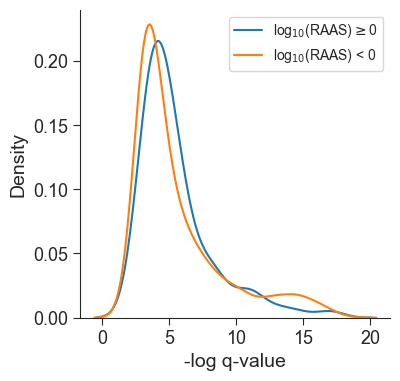

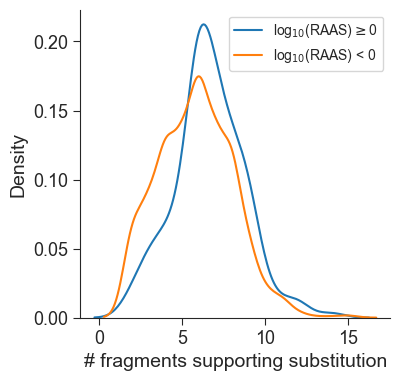

In [256]:
# cumulative density of q-values and PEPs across all datasets and samples stratified by RAAS
# generate a dictionary with PEP values and N fragments for all SAAP in all datasets 
paas_pep_dict = {}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    mtp_dict = pickle.load(open(data_dir + 'Ion_validated_MTP_dict.p', 'rb'))
    mtp_quant_dict = pickle.load(open(data_dir + 'MTP_quant_dict.p', 'rb'))

    plot_rows = []
    plot_cols = ['Dataset', 'Sample', 'SAAP', 'SAAP_val_idx', 'DP PEP', 'SAAP PEP', 'SAAP q', 'SAAP Precursor Intensity','BP Precursor Intensity', 'Precursor RAAS', 'N fragments']
    for s in samples:
        s_dict = mtp_dict[s]
        for k, paas in s_dict['mistranslated sequence'].items():
            paas_pep = s_dict['Posterior subs probability'][k]
            paas_q = s_dict['q-value'][k]
            dp_pep = s_dict['DP PEP'][k]
            n_frags = s_dict['fragment_evidence'][k]
            q_dict = [i for i,v in mtp_quant_dict.items() if v['MTP_seq']==paas]
            if len(q_dict)>0:
                q_dict = mtp_quant_dict[q_dict[0]]
                paas_prec = q_dict['MTP_PrecInt'][s]
                bp_prec = q_dict['BP_PrecInt'][s]
                raas = q_dict['Prec_ratio'][s]
                if (~np.isnan(raas)) and (~np.isinf(raas)):
                    plot_rows.append([ds, s, paas, k, dp_pep, paas_pep, paas_q, paas_prec, bp_prec, raas, n_frags])
    plot_df = pd.DataFrame(plot_rows, columns=plot_cols)   
    paas_pep_dict[ds] = plot_df

pickle.dump(paas_pep_dict, open(OUTDIR+'SAAP_PEP_dfs.p', 'wb'))

# create data frame for plot 
all_ds_plot_df = pd.concat([v for k,v in paas_pep_dict.items()])
all_ds_plot_df['RAAS group'] = ['$\geq$0' if raas>=0 else '<0' for i,raas in list(enumerate(all_ds_plot_df['Precursor RAAS'].values))]
all_ds_plot_df = all_ds_plot_df.loc[all_ds_plot_df['SAAP q']<=0.01]

# plot histogram of confidence values stratified by RAAS
fig,ax = plt.subplots(figsize=(4,4))
all_ds_plot_df['-log q'] = [-np.log10(x) for x in all_ds_plot_df['SAAP q']]
high_raas_df = all_ds_plot_df.loc[all_ds_plot_df['Precursor RAAS']>=0]
low_raas_df = all_ds_plot_df.loc[all_ds_plot_df['Precursor RAAS']<0]
sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='-log q', fill=False, palette='colorblind', label='log$_{10}$(RAAS)$\geq$0')
sns.kdeplot(data = low_raas_df.loc[~np.isinf(low_raas_df['-log q'])], x='-log q', fill=False, label='log$_{10}$(RAAS) < 0', palette='colorblind')
sns.despine()
ax.tick_params('both', labelsize=13)
plt.ylabel('Density', fontsize=14)
plt.xlabel('-log q-value', fontsize=14)
plt.legend(fontsize=10)
plt.tick_params(axis='both', length=5)

plt.savefig(PLOT_DIR+'RAASgroup_logq_hist.pdf', bbox_inches='tight')

# plot histogram of N fragments on substitution site stratified by RAAS
fig,ax = plt.subplots(figsize=(4,4))
sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='N fragments', fill=False, palette='colorblind', label='log$_{10}$(RAAS)$\geq$0')
sns.kdeplot(data = low_raas_df.loc[~np.isinf(low_raas_df['-log q'])], x='N fragments', fill=False, label='log$_{10}$(RAAS) < 0', palette='colorblind')
sns.despine()
ax.tick_params('both', labelsize=13)
plt.ylabel('Density', fontsize=14)
plt.xlabel('# fragments supporting substitution', fontsize=14)
# plt.yticks([0,0.03,0.06,0.09,0.12])
plt.tick_params(axis='both', length=5)
plt.legend(loc='upper right', fontsize=10)

plt.savefig(PLOT_DIR+'RAASgroup_Nfrags_hist.pdf', bbox_inches='tight')

### Mass errors for SAAPs and main peptides

In [257]:
# Function to find median mass error for a SAAP
def saap_mass_error(saap, s_saap_dict):
    """Median aa-substitution mass error (ppm) for a SAAP; NaN if the SAAP is absent."""
    saap_idx = [k for k, v in s_saap_dict['mistranslated sequence'].items() if v == saap]
    if not saap_idx:
        print(f"WARNING: SAAP {saap} not found in mistranslated sequence")
        return np.nan
    return np.median([s_saap_dict['aa subs mass error (ppm)'][k] for k in saap_idx])

Aorta S1 rows: 944
              MTP_seq  Reporter_RAAS
Row Number                          
0           SALSGLLHR      -1.534776
1           SALSGLLHR      -1.607140
2           SALSGLLHR      -1.623710
3           SALSGLLHR      -1.616215
4           SALSGLLHR      -1.649804
High SAAP: ['LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'LVTADTIK', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'RQLEEAEEESQR', 'DLYANDVLSGGTTMYPGIADR', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDLKGPDLDIK', 'VEGDL

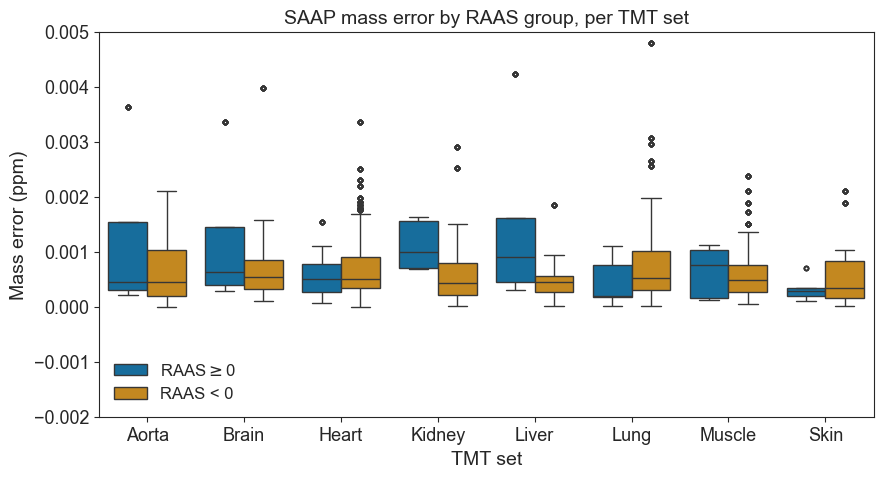

In [258]:
# mass error analysis

SAAP_quant_df['tmt_set'] = SAAP_quant_df['tmt_set'].str.strip("[]'\"")

# create a dictionary with mass errors of SAAP with high and low RAAS
mass_err_dict = {ds:{'High RAAS mass error':[], 'Low RAAS mass error':[]} for ds in datasets}
for ds in datasets:
    data_dir = data_dir_list[datasets.index(ds)]
    ds_prec_df = SAAP_quant_df.loc[SAAP_quant_df['Dataset']==ds]   
    saap_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    samples = samples_list[datasets.index(ds)]
    # print(samples)
    for s in samples:
        s_saap_dict = saap_dict[s]
        # print(s_saap_dict.keys())
        if 'aa subs mass error (ppm)' in s_saap_dict.keys():
            s_prec_df = ds_prec_df.loc[ds_prec_df['tmt_set']==s]
            print(f"{ds} {s} rows: {len(s_prec_df)}")
            print(s_prec_df[['MTP_seq', 'Reporter_RAAS']].head())

            high_saap = s_prec_df.loc[s_prec_df['Reporter_RAAS']>=0, 'MTP_seq'].to_list()
            low_saap = s_prec_df.loc[s_prec_df['Reporter_RAAS']<0, 'MTP_seq'].to_list()
            print(f"High SAAP: {high_saap}")
            print(f"Low SAAP: {low_saap}")

            high_errs = [saap_mass_error(saap, s_saap_dict) for saap in high_saap]
            low_errs = [saap_mass_error(saap, s_saap_dict) for saap in low_saap]
            mass_err_dict[ds]['High RAAS mass error']  = mass_err_dict[ds]['High RAAS mass error'] + high_errs
            mass_err_dict[ds]['Low RAAS mass error']  = mass_err_dict[ds]['Low RAAS mass error'] + low_errs 
pickle.dump(mass_err_dict, open(OUTDIR+'High_v_low_RAAS_mass_error_ppm.p','wb'))

# create dataframe for plot
plot_df_list = []
for ds in datasets:
    # print(ds)
    ds_me_dict = mass_err_dict[ds]
    high_errs = ds_me_dict['High RAAS mass error']
    low_errs = ds_me_dict['Low RAAS mass error']
    ds_list = [ds]*len(high_errs+low_errs)
    high_str_list = [r'RAAS$\geq$0']*len(high_errs)
    low_str_list = ['RAAS < 0']*len(low_errs)
    ds_plot_df = pd.DataFrame(zip(ds_list, high_errs+low_errs, high_str_list+low_str_list), columns=['Dataset', 'aa subs mass error (ppm)', 'Peptide type'])
    plot_df_list.append(ds_plot_df)
plot_df = pd.concat(plot_df_list)

# plot distributions of mass errors for SAAP with high and low RAAS
fig,ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=plot_df, x='Dataset', hue='Peptide type', y='aa subs mass error (ppm)', linewidth=1, fliersize=3, palette='colorblind')
plt.ylabel('Mass error (ppm)', fontsize=14)
ax.tick_params('both', labelsize=13)
plt.xlabel('TMT set',fontsize=14)
plt.ylim(-0.002, 0.005)
plt.legend(loc='lower left', fontsize=12, frameon=False, ncol=1)
plt.title('SAAP mass error by RAAS group, per TMT set', fontsize=14)

plt.savefig(PLOT_DIR+'HighvLow_RAAS_Mass_error_boxplots.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'HighvLow_RAAS_Mass_error_boxplots.png', dpi=600, bbox_inches='tight')

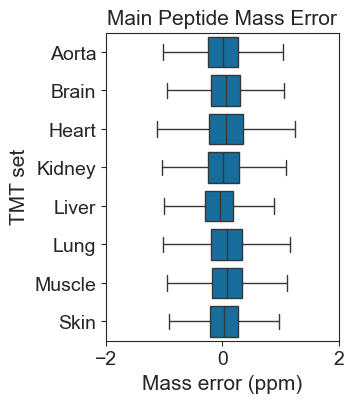

In [259]:
# Main peptide mass error 
# generate a dictionary with mass error data
mass_err_dict = {ds:{'Main peptide mass error':[], 'SAAP mass error':[]} for ds in datasets}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    mainpep_dict = pickle.load(open(data_dir+'DP_search_evidence_dict.p','rb'))
    samples = samples_list[datasets.index(ds)]
    for s in samples:
        errs = mainpep_dict[s]['Mass error [ppm]']
        errs = [x for x in errs if np.abs(x)<10000]
        mass_err_dict[ds]['Main peptide mass error'] = mass_err_dict[ds]['Main peptide mass error']+errs

pickle.dump(mass_err_dict, open(OUTDIR+'Main_peptide_mass_error_ppm.p','wb'))
#mass_err_dict = pickle.load(open(OUTDIR+'Main_peptide_mass_error_ppm.p','rb'))

# plot main peptide mass error boxplots
plot_df_list = []
for ds in datasets:
    # print(ds)
    ds_me_dict = mass_err_dict[ds]
    main_pep_errs = ds_me_dict['Main peptide mass error']
    saap_errs = [np.abs(x) for x in ds_me_dict['SAAP mass error']]
    saap_errs = saap_errs + [-x for x in saap_errs]
    ds_list = [ds]*len(main_pep_errs+saap_errs)
    main_str_list = ['Main peptide']*len(main_pep_errs)
    saap_str_list = ['SAAP']*len(saap_errs)

    ds_plot_df = pd.DataFrame(zip(ds_list, main_pep_errs+saap_errs, main_str_list+saap_str_list), columns=['Dataset', 'Mass error (ppm)', 'Peptide type'])
    plot_df_list.append(ds_plot_df)
plot_df = pd.concat(plot_df_list)

fig,ax = plt.subplots(figsize=(3,4))
sns.boxplot(data=plot_df, y='Dataset', hue='Peptide type', x='Mass error (ppm)', linewidth=1, fliersize=0, palette='colorblind')
plt.xlabel('Mass error (ppm)', fontsize=15)
ax.tick_params('both', labelsize=14)
plt.ylabel('TMT set', fontsize=15)
plt.xlim([-2,2])
plt.title('Main Peptide Mass Error',fontsize=15)
# plt.legend(loc='lower left', fontsize=14, bbox_to_anchor=(-0.2,0.97), frameon=False, ncol=2, handletextpad=0.1, columnspacing=0.8)
ax.get_legend().remove()

plt.savefig(PLOT_DIR+'Mainpep_Mass_error_boxplots.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Mainpep_Mass_error_boxplots.png',dpi=600, bbox_inches='tight')

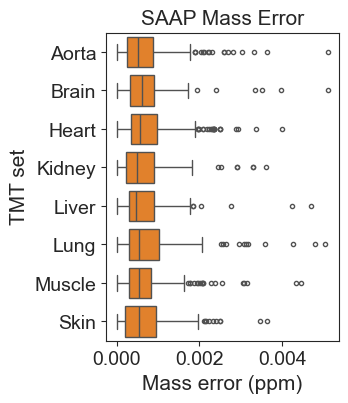

In [260]:
# SAAP mass error 
mass_err_dict = {ds:{'SAAP mass error':[]} for ds in datasets}
for ds in datasets:
    # print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    saap_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    samples = samples_list[datasets.index(ds)]
    for s in samples:
        s_saap_dict = saap_dict[s]
        if 'aa subs mass error (ppm)' in s_saap_dict.keys():
            saap_errs = [saap_mass_error(saap, s_saap_dict) for saap in s_saap_dict['mistranslated sequence'].values()]
            mass_err_dict[ds]['SAAP mass error'] = mass_err_dict[ds]['SAAP mass error']+saap_errs
pickle.dump(mass_err_dict, open(OUTDIR+'SAAP_mass_error_ppm.p','wb'))
#mass_err_dict = pickle.load(open(OUTDIR+'SAAP_mass_error_ppm.p','rb'))

# plot SAAP mass error boxplots
plot_df_list = []
for ds in datasets:
    # print(ds)
    ds_me_dict = mass_err_dict[ds]
    saap_errs = ds_me_dict['SAAP mass error']
    ds_list = [ds]*len(saap_errs)
    saap_str_list = ['SAAP']*len(saap_errs)

    ds_plot_df = pd.DataFrame(zip(ds_list, saap_errs, saap_str_list), columns=['Dataset', 'Mass error (ppm)', 'Peptide type'])
    plot_df_list.append(ds_plot_df)
plot_df = pd.concat(plot_df_list)
fig,ax = plt.subplots(figsize=(3,4))
sns.boxplot(data=plot_df, y='Dataset', x='Mass error (ppm)', linewidth=1, fliersize=3, color=colors[1])
plt.xlabel('Mass error (ppm)', fontsize=15)
ax.tick_params('both', labelsize=14)
plt.ylabel('TMT set',fontsize=15)
plt.xscale('linear')
plt.title('SAAP Mass Error',fontsize=15)
# plt.xlim([-0.001,0.0025])

plt.savefig(PLOT_DIR+'SAAP_mass_error_boxplots.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'SAAP_mass_error_boxplots.png', dpi=600,bbox_inches='tight')

### N SAAPs post-filtering/validation

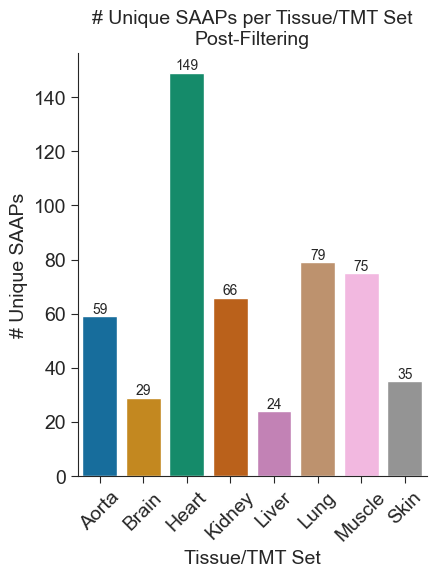

In [261]:
# N SAAPs per dataset post-filtering
plot_rows = []
plot_cols = ['Dataset','N SAAPs']

for ds in datasets:
    ds_df = SAAP_quant_df[SAAP_quant_df['Dataset']==ds]
    n_saaps = ds_df['MTP_seq'].nunique()
    plot_rows.append([ds,n_saaps])

plot_df = pd.DataFrame(plot_rows,columns=plot_cols)
sns.set_style('ticks')

fig,ax = plt.subplots(figsize=(4.5,5.5))
sns.barplot(data=plot_df,x='Dataset',y='N SAAPs',hue='Dataset',palette='colorblind',legend=False)
sns.despine()
plt.tick_params('both',labelsize=14)
plt.xticks(rotation=45)
plt.xlabel('Tissue/TMT Set',fontsize=14)
plt.ylabel('# Unique SAAPs',fontsize=14)
plt.title('# Unique SAAPs per Tissue/TMT Set\nPost-Filtering',fontsize=14)
plt.tick_params(axis='both',length=5)

for container in ax.containers:
    ax.bar_label(container)

plt.savefig(PLOT_DIR+'N_SAAPs_per_dataset_postfiltering.pdf',bbox_inches='tight')
plt.savefig(PLOT_DIR+'N_SAAPs_per_dataset_postfiltering.png',dpi=600,bbox_inches='tight')

# 2. RAAS

## 2a Global Metrics

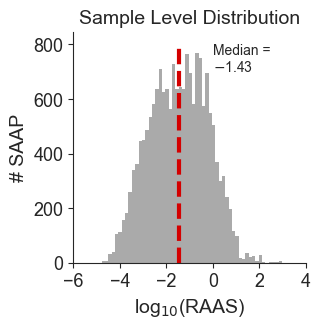

In [262]:
# sample-level RAAS distribution - all datasets in one distribution
sns.set_style('ticks')
fig,ax = plt.subplots(figsize=(3,3))
ratios = []
for i,ds in enumerate(datasets):
    ratio_data = [x for x in SAAP_quant_df_list[i]['Reporter_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    ratios = ratios + ratio_data
sns.histplot(ratios, color='#aaaaaa', linewidth=0, alpha=1)
plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--', color='#d40000', linewidth=3)
ax.annotate('Median =\n$-$'+str(np.abs(np.round(np.median(ratios), 2))), (0,700), fontsize=10)
ax.set_ylabel(r'# SAAP', fontsize=14)
ax.set_xlabel(r'log$_{10}$(RAAS)', fontsize=14)
ax.tick_params('both',labelsize=13)
ax.set_title(r'Sample Level Distribution',fontsize=14)
ax.set_xticks([-6,-4,-2,0,2,4]);
sns.despine()

plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_onehistplot.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_onehistplot.png',dpi=600, bbox_inches='tight')

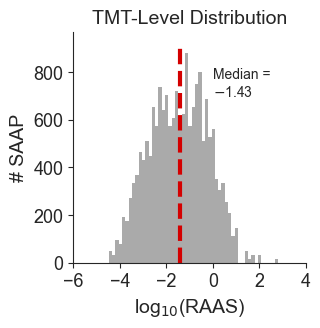

In [263]:
# tmt-level RAAS distribution - all datasets in one distribution
sns.set_style('ticks')
fig,ax = plt.subplots(figsize=(3,3))
ratios = []
for i,ds in enumerate(datasets):
    ratio_data = [x for x in SAAP_quant_df_list[i]['Prec_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    ratios = ratios + ratio_data
sns.histplot(ratios, color='#aaaaaa', linewidth=0, alpha=1)
plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--', color='#d40000', linewidth=3)
ax.annotate('Median =\n$-$'+str(np.abs(np.round(np.median(ratios), 2))), (0,700), fontsize=10)
ax.set_ylabel(r'# SAAP', fontsize=14)
ax.set_xlabel(r'log$_{10}$(RAAS)', fontsize=14)
ax.tick_params('both',labelsize=13)
ax.set_xticks([-6,-4,-2,0,2,4])
ax.set_title(r'TMT-Level Distribution',fontsize=14)
sns.despine()
plt.savefig(PLOT_DIR+'tmt_level_RAAS_allDS_onehistplot.pdf', bbox_inches='tight')

## 2b Precursor and Reporter RAAS Agreeability

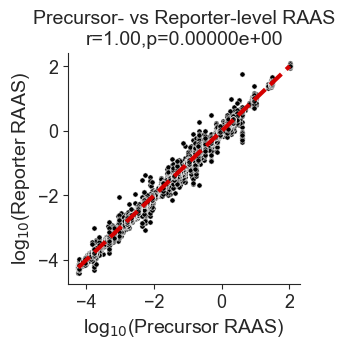

In [264]:
# Precursor vs Reporter RAAS Level Agreeability
fig,ax = plt.subplots(figsize=(3,3))

raas_df=SAAP_quant_df.copy()
raas_df['log10_Prec_RAAS']=raas_df['Prec_RAAS'].replace([np.inf,-np.inf],np.nan)
raas_df['log10_Reporter_RAAS']=raas_df['Reporter_RAAS'].replace([np.inf,-np.inf],np.nan)
raas_df=raas_df.dropna(subset=['log10_Prec_RAAS','log10_Reporter_RAAS'])

r,p=sp.stats.pearsonr(raas_df['log10_Prec_RAAS'],raas_df['log10_Reporter_RAAS'])
sns.scatterplot(data=raas_df,x='log10_Prec_RAAS',y='log10_Reporter_RAAS',s=14,alpha=1,color="#000000",edgecolor='white',linewidth=0.36,ax=ax)
sns.regplot(data=raas_df,x='log10_Prec_RAAS',y='log10_Reporter_RAAS',scatter=False,line_kws={'color':'#d40000','linestyle':'--','linewidth':3,'zorder':10},ax=ax)

ax.tick_params('both',labelsize=13)
plt.xlabel('log$_{10}$(Precursor RAAS)',fontsize=14)
plt.ylabel('log$_{10}$(Reporter RAAS)',fontsize=14)
# ax.set_xticks([-4,-2,0,2])
plt.title(f'Precursor- vs Reporter-level RAAS\nr={r:.2f},p={p:.5e}',fontsize=14)
sns.despine()
plt.savefig(PLOT_DIR+'MS1_MS2_RAAS_correlation.pdf',bbox_inches='tight')

## 2c Tissue-level RAAS Distributions

In [265]:
# Formatting function for bihistogram plots
def bihist(y1, y2, nbins=10, h=None, color='#aaaaaa'):
    """
    Function used to create violin plots as bihistograms with no smoothing.
    h is an axis handle. If not present, a new figure is created.
    """
    if h is None: h = plt.figure().add_subplot(111)
    ymin = np.floor(np.minimum(min(y1), min(y2)))
    ymax = np.ceil(np.maximum(max(y1), max(y2)))
    bins = np.linspace(ymin, ymax, nbins)
    n1, bins1, patch1 = h.hist(y1, bins, orientation="horizontal", color=color, edgecolor=None, linewidth=0, rwidth=1)
    n2, bins2, patch2 = h.hist(y2, bins, orientation="horizontal", color=color, edgecolor=None, linewidth=0, rwidth=1)
    xmax = 0
    for i in patch1:
        i.set_edgecolor(None)
        width = i.get_width()
        if width > xmax: xmax = width
    xmin = 0
    for i in patch2:
        i.set_edgecolor(None)
        width = i.get_width()
        width = -width
        i.set_width(width)
        if width < xmin: xmin = width
    h.set_xlim(xmin*1.1, xmax*1.1)
    h.figure.canvas.draw()

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_7154/2702066803.py:30: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)


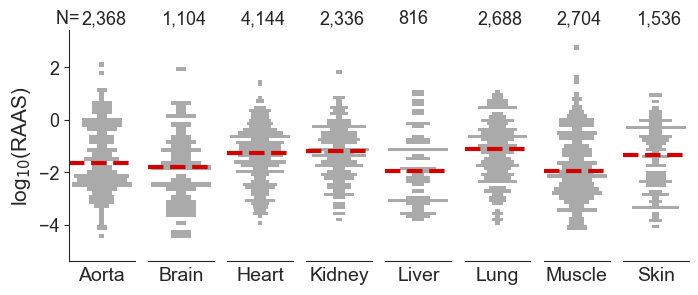

In [266]:
#TMT-level RAAS distribution (precursor ion RAAS distribution), code adapted from Tsour et al 2024
# N = number of quantified SAAP precursor-ion ratios
tissue_order = ['Aorta','Brain','Heart','Kidney','Liver','Lung','Muscle','Skin']

fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)

sns.set_style('ticks')
sns.despine()
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

medians = [np.nanmedian(SAAP_quant_df_list[i]['Prec_RAAS'].values) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians)) # sort by median instead
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in SAAP_quant_df_list[i]['Prec_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=50,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'TMT_level_RAAS_allDS.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'TMT_level_RAAS_allDS.png',dpi=600, bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_7154/1393792248.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)


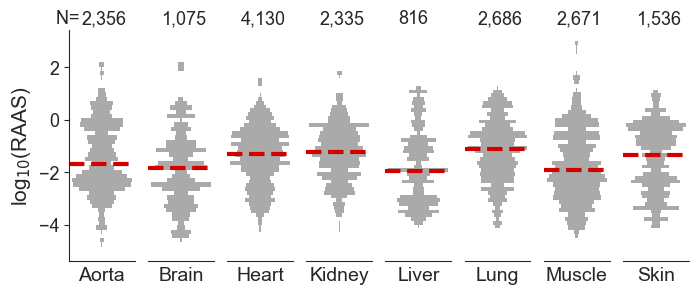

In [267]:
# sample/reporter ion level RAAS distributions for each dataset, code adapted from Tsour et al 2024
# N = number of quantified SAAP reporter-ion ratios

fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)

sns.set_style('ticks')
sns.despine()
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

medians = [np.nanmedian(SAAP_quant_df_list[i]['Reporter_RAAS'].values) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in SAAP_quant_df_list[i]['Reporter_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=50,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--r', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_nogrid.pdf', bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_7154/3920553453.py:16: RuntimeWarning: All-NaN slice encountered
  saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]


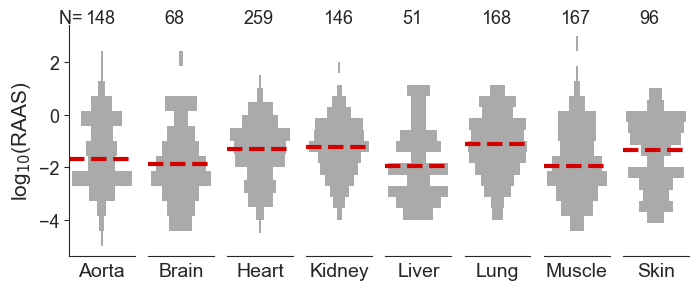

In [268]:
# Median RAAS distributions for all unique SAAP 
fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)
sns.set_style('ticks')
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

saap_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    saap = list(set(reporter_quant_df['MTP_seq'].values))
    saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]
    saap_median_values_list.append(saap_medians)
        
medians = [np.nanmedian(saap_median_values_list[i]) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in saap_median_values_list[i] if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=15,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.15,1.01), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.25,1.01), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'SAAP_median_RAAS_allDS.pdf', bbox_inches='tight')

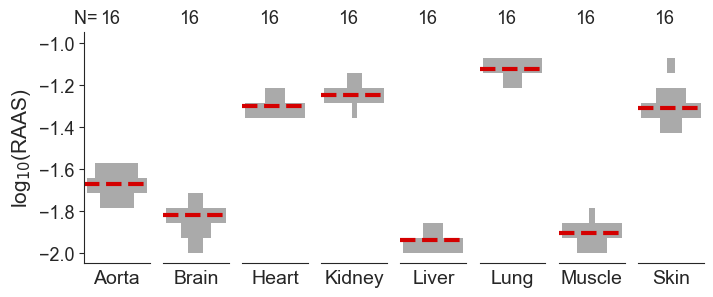

In [269]:
# Sample median RAAS distributions
fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)
sns.set_style('ticks')
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

sample_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    samples = list(set(reporter_quant_df['Sample'].values))
    sample_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['Sample']==s, 'Reporter_RAAS'].values) for s in samples]
    sample_median_values_list.append(sample_medians)
        
medians = [np.nanmedian(sample_median_values_list[i]) for i in range(len(datasets)-1)]
med_sort_idx = [tissue_order.index(ds) for ds in datasets]
# med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in sample_median_values_list[i] if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=15,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.15,1.04), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.25,1.04), xycoords='axes fraction', fontsize=13)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--', color='#d40000', linewidth=3)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

#plt.annotate('Cancer and normal adjacent tissue', (0.14,0.97), xycoords='figure fraction')
#plt.show()
plt.savefig(PLOT_DIR+'Sample_median_RAAS_allDS.pdf', bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_7154/3417300705.py:16: RuntimeWarning: All-NaN slice encountered
  saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]


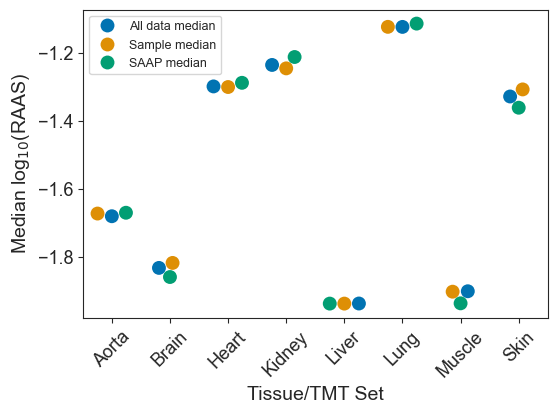

In [270]:
# Medians for all data, sample, and SAAP-level RAAS 
all_medians = [np.nanmedian(SAAP_quant_df_list[i]['Reporter_RAAS'].values) for i in range(len(datasets)-1)]
all_medians.append(np.nanmedian(SAAP_quant_df_list[-1]['Reporter_RAAS'].values))

sample_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    samples = list(set(reporter_quant_df['Sample'].values))
    sample_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['Sample']==s, 'Reporter_RAAS'].values) for s in samples]
    sample_median_values_list.append(sample_medians)

saap_median_values_list = []
for i,ds in enumerate(datasets):
    reporter_quant_df = SAAP_quant_df_list[i]
    saap = list(set(reporter_quant_df['MTP_seq'].values))
    saap_medians = [np.nanmedian(reporter_quant_df.loc[reporter_quant_df['MTP_seq']==s, 'Reporter_RAAS'].values) for s in saap]
    saap_median_values_list.append(saap_medians)

sample_medians = [np.nanmedian(sample_median_values_list[i]) for i in range(len(datasets))]
saap_medians = [np.nanmedian(saap_median_values_list[i]) for i in range(len(datasets))]

plot_rows = []
plot_cols = ['Dataset', 'Median RAAS', 'Median type']
for m, median in enumerate(all_medians):
    plot_rows.append([datasets[m], median, 'All data median'])
for m, median in enumerate(sample_medians):
    plot_rows.append([datasets[m], median, 'Sample median'])
for m, median in enumerate(saap_medians):
    plot_rows.append([datasets[m], median, 'SAAP median'])
    
plot_df = pd.DataFrame(plot_rows, columns=plot_cols)    

fig,ax = plt.subplots(figsize=(6,4))
sns.swarmplot(data=plot_df, x='Dataset', y='Median RAAS', hue='Median type', s=10,
              palette='colorblind',order=tissue_order)
plt.legend(loc='upper left',title='', fontsize=9)
ax.tick_params('both', labelsize=13)
plt.xticks(rotation=45)
plt.ylabel('Median log$_{10}$(RAAS)', fontsize=14)
plt.xlabel('Tissue/TMT Set',fontsize=14)
plt.savefig(PLOT_DIR+'RAAS_distribution_median_comparison_swarmplot.pdf', bbox_inches='tight')

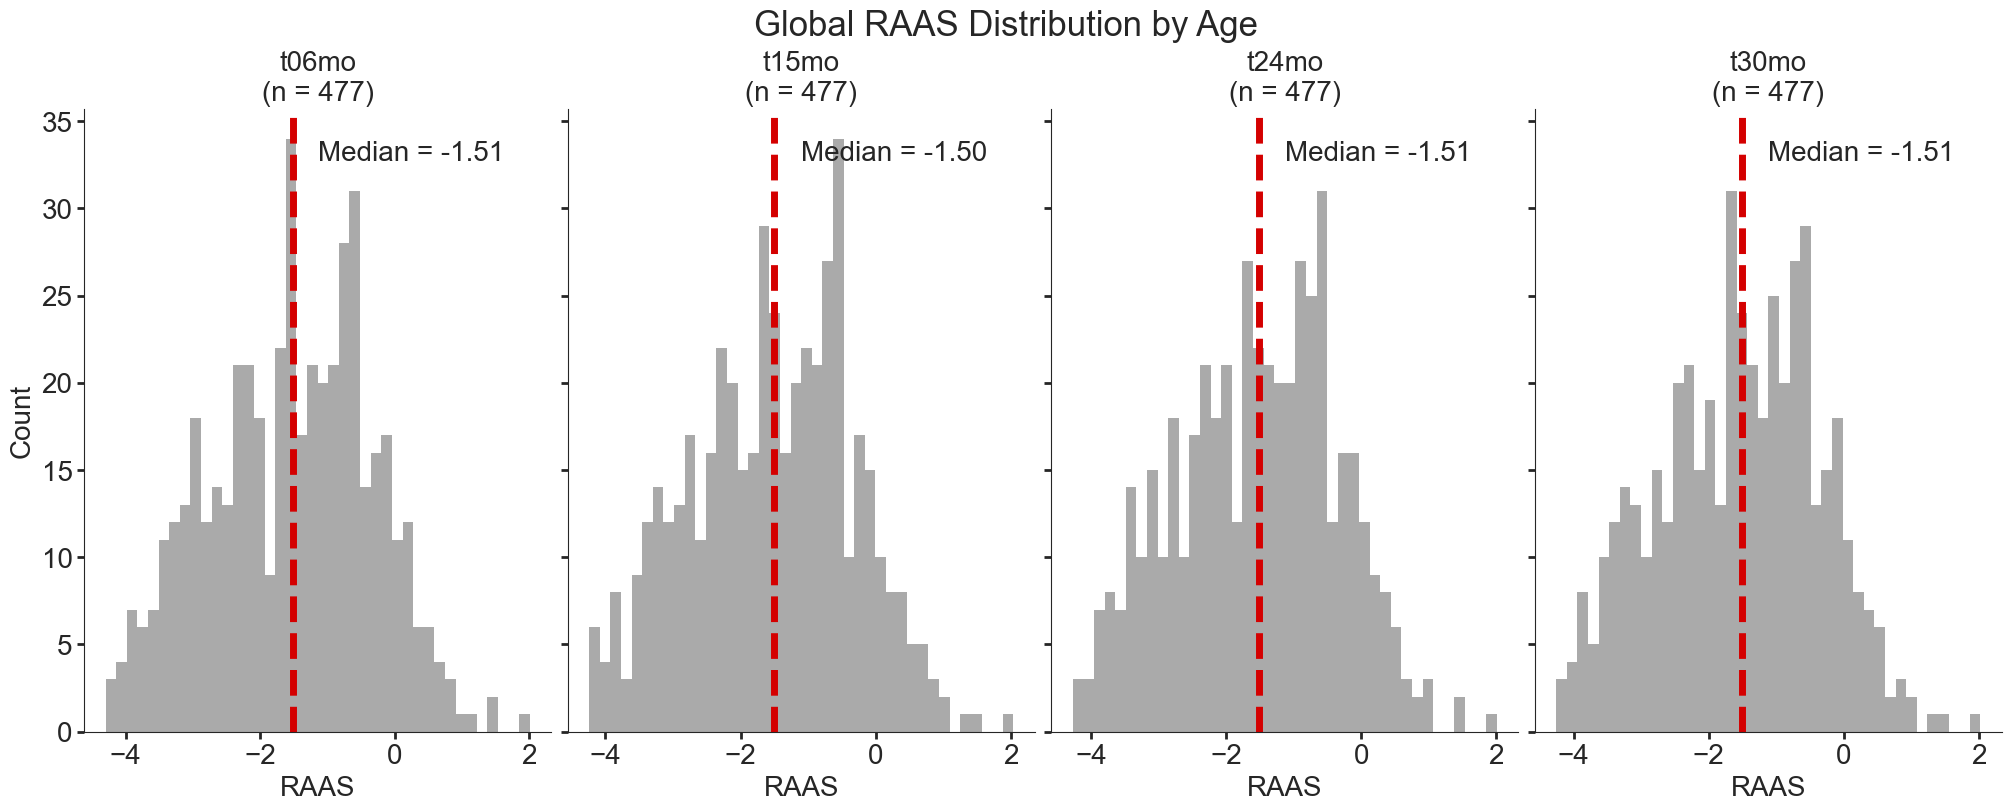

In [271]:
# sample level RAAS distribution by age
# one SAAP RAAS value is the median of its replicates 

age_df = SAAP_quant_df.copy()
age_df = age_df.groupby(['Dataset','MTP_seq','Sample Type'])['Reporter_RAAS'].median().reset_index()
ages = age_df['Sample Type'].unique()
num_ages = len(ages)

fig,axes = plt.subplots(1, num_ages, figsize=(5*num_ages, 8), sharey=True, constrained_layout=True)

for i, age in enumerate(ages):
    ax = axes[i]
    subset = age_df[age_df['Sample Type'] == age]
    vals = subset['Reporter_RAAS'].values
    vals = vals[np.isfinite(vals)] 

    sns.histplot(vals, bins=40, kde=False, ax=ax,
                 color='#aaaaaa', edgecolor=None, linewidth=0,alpha=1)

    median = np.median(vals)
    ax.axvline(median, color='#d40000', linestyle='--', linewidth=5)

    n = len(vals)
    ax.set_title(f'{age}\n(n = {n})', fontsize=20)
    ax.tick_params(axis='both', labelsize=20, length=5, width=2)
    ax.set_xlabel('RAAS', fontsize=20)
    ax.set_ylabel('Count', fontsize=20)
    ax.grid(False)
    sns.despine()

    ax.text(0.5, 0.95, f'Median = {median:.2f}', transform=ax.transAxes,
            fontsize=20, verticalalignment='top')

plt.suptitle('Global RAAS Distribution by Age',fontsize=25)
plt.savefig(PLOT_DIR + 'Global_RAAS_by_age.pdf')
plt.show()

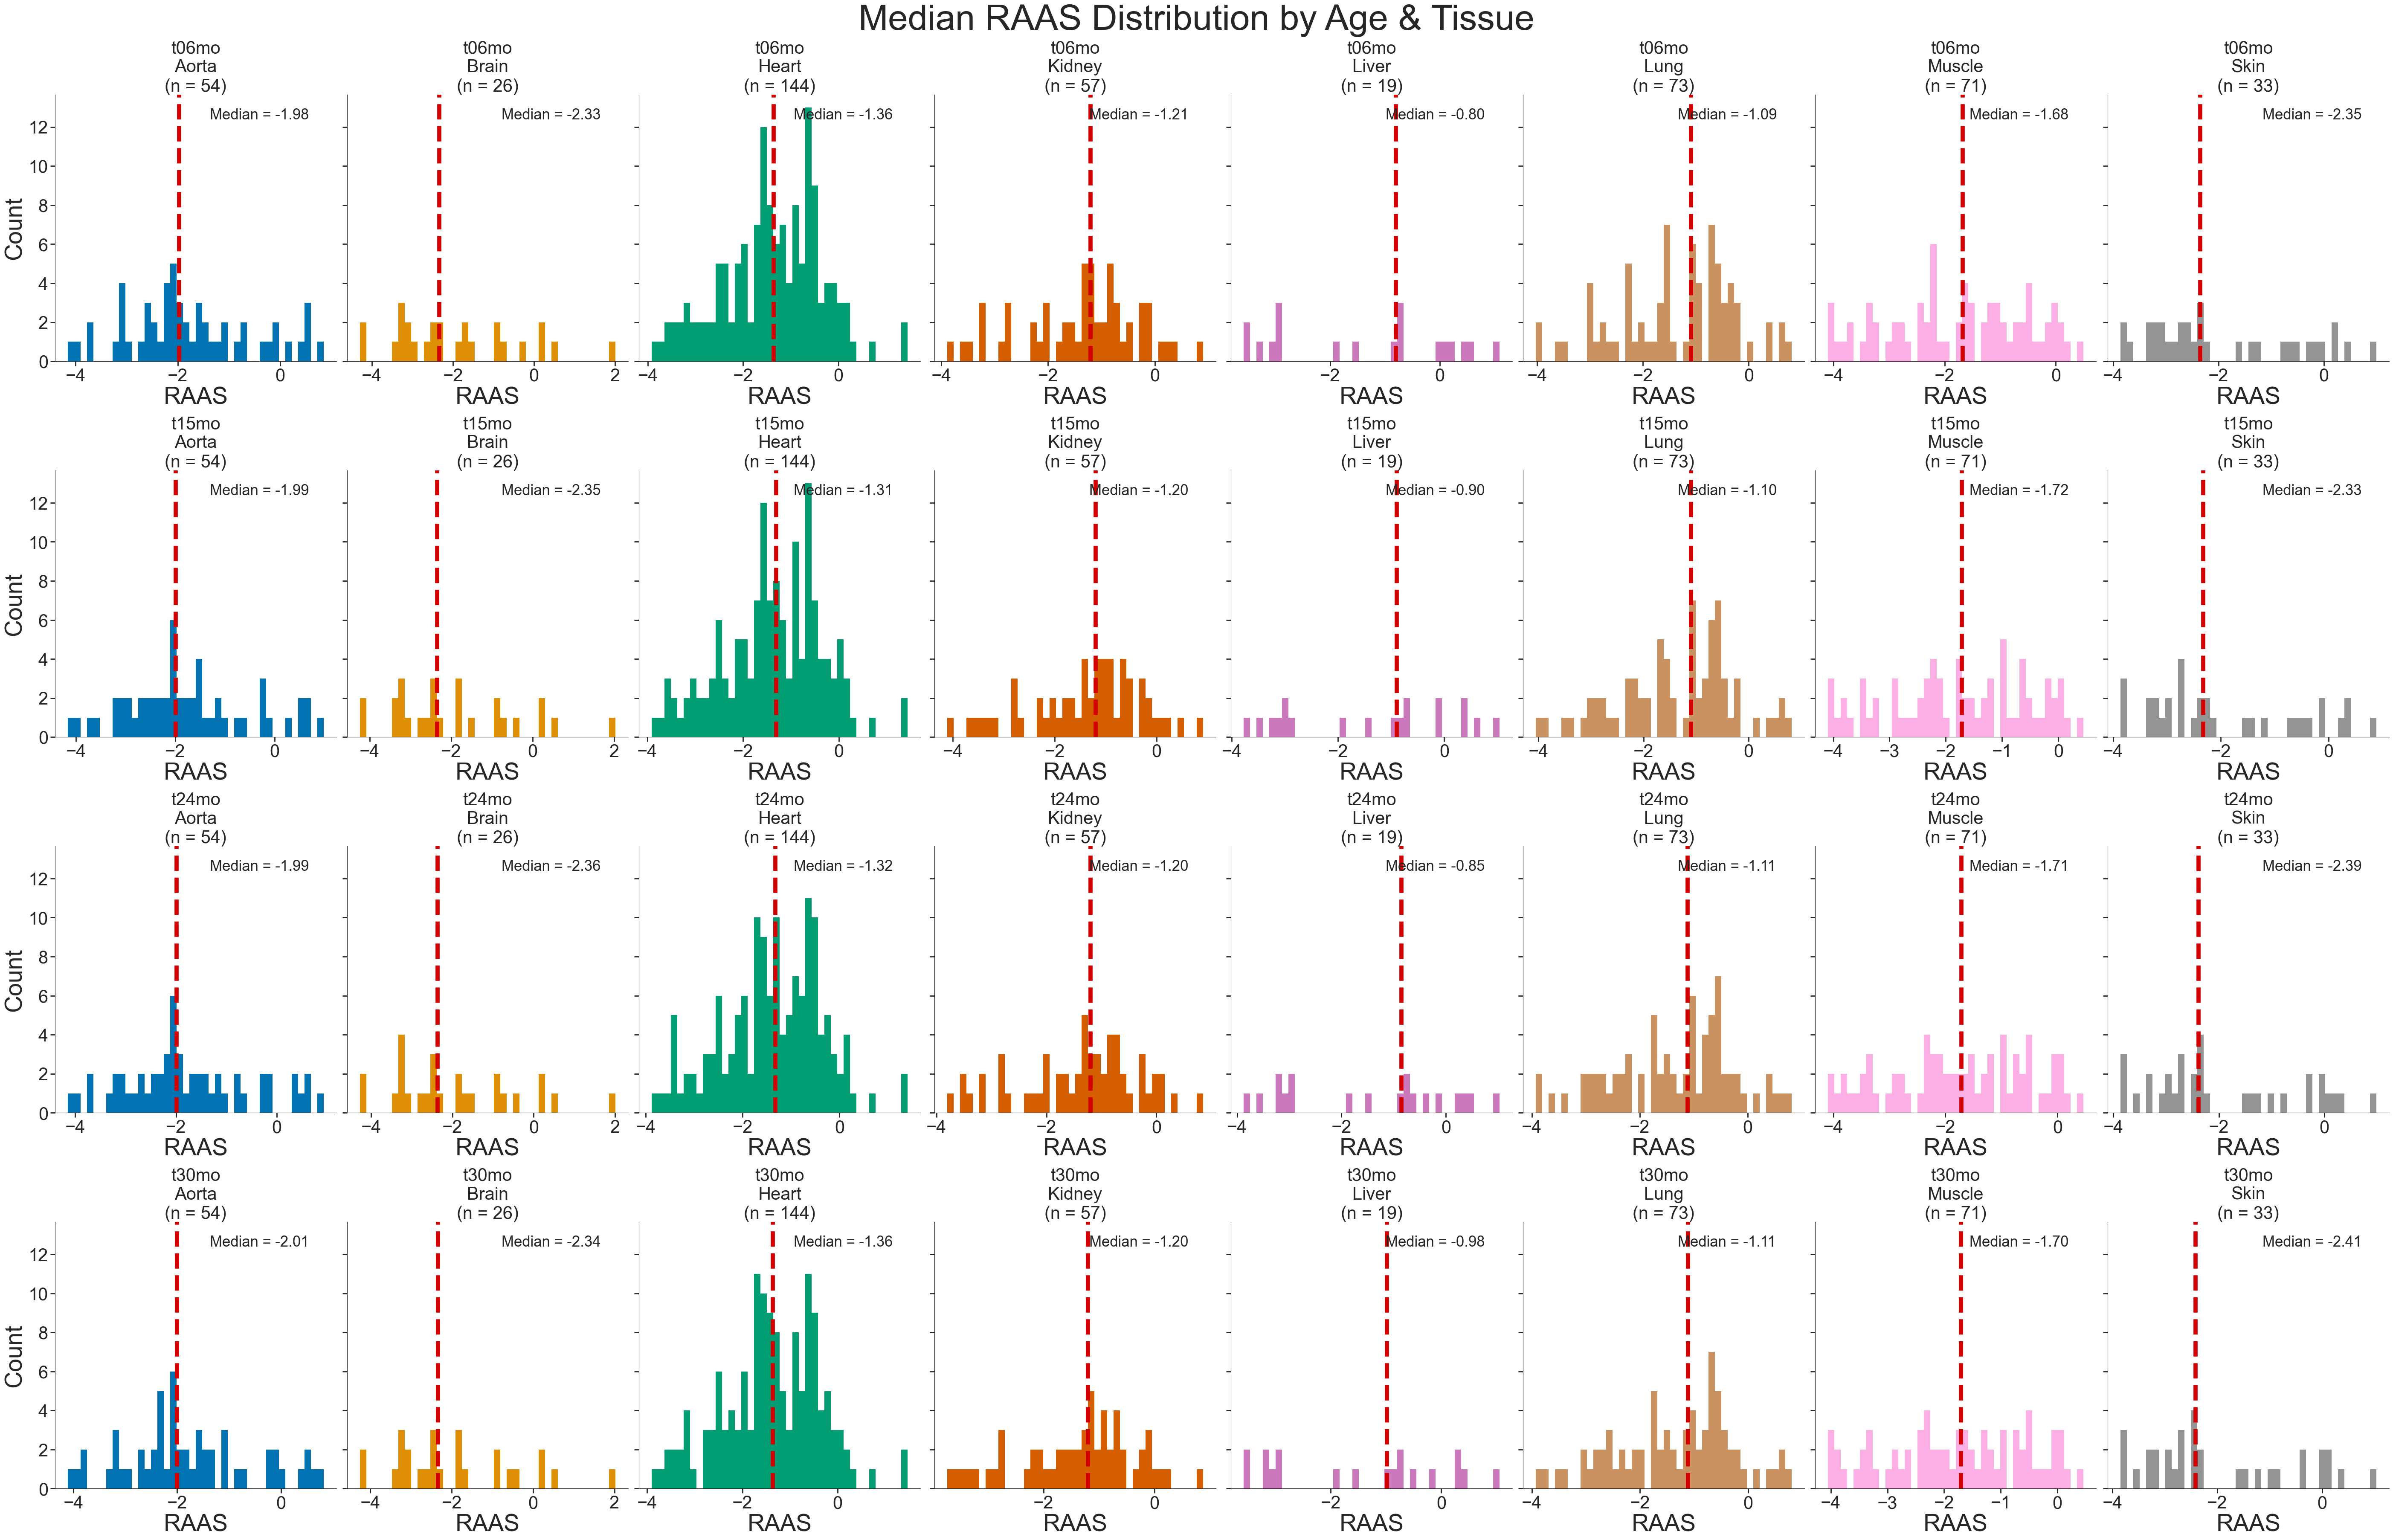

In [272]:
# sample level RAAS distribution by tissue by age
# one SAAP RAAS value is the median of its replicates 

tissue_age_df = SAAP_quant_df.copy()
tissue_age_df = tissue_age_df.groupby(['Dataset','MTP_seq','Sample Type'])['Reporter_RAAS'].median().reset_index()
ages = tissue_age_df['Sample Type'].unique()
tissues = tissue_age_df['Dataset'].unique()

palette = sns.color_palette('colorblind', len(tissues))
tissue_colors = {
    tissue: palette[i]
    for i, tissue in enumerate(tissues)
}

num_ages = len(ages)
num_tissues = len(tissues)

fig,axes = plt.subplots(num_ages, num_tissues, figsize=(7*num_tissues, 9*num_ages), sharey=True, constrained_layout=True)

for i, age in enumerate(ages):
    for j, tissue in enumerate(tissues):
        ax = axes[i,j]
        subset = tissue_age_df[(tissue_age_df['Sample Type'] == age) &
                               (tissue_age_df['Dataset'] == tissue)]
        vals = subset['Reporter_RAAS'].values
        vals = vals[np.isfinite(vals)]   

        sns.histplot(vals, bins=40, kde=False, ax=ax,
                     color=tissue_colors[tissue], edgecolor=None, linewidth=0,alpha=1)

        median = np.median(vals) if len(vals) else np.nan
        ax.axvline(median, color='#d40000', linestyle='--', linewidth=7)

        n = len(vals)
        ax.set_title(f'{age}\n{tissue}\n(n = {n})', fontsize=30)
        ax.tick_params(axis='both', labelsize=30, length=8, width=2)
        ax.set_xlabel('RAAS', fontsize=40)
        ax.set_ylabel('Count', fontsize=40)
        ax.grid(False)
        sns.despine()

        ax.text(0.55, 0.95, f'Median = {median:.2f}', transform=ax.transAxes,
                fontsize=25, verticalalignment='top')

plt.suptitle('Median RAAS Distribution by Age & Tissue',fontsize=60)
plt.savefig(PLOT_DIR + 'Global_RAAS_by_agextissue.pdf')
plt.show()

# 3. RAAS Changes Associated with Aging

## 3a Data pre-processing

In [273]:
COMPLETE_SAAPS_ONLY = True # toggle True if wanting SAAPs detected in EVERY age group
SAAP_KEYS     = ['MTP_seq', 'BP_seq', 'aa_sub']   
age_order = ['t06mo', 't15mo', 't24mo', 't30mo']
tissue_order = ['Aorta','Brain','Heart','Kidney','Liver','Lung','Muscle','Skin']

# Functions to prepare data for analysis
def data_prep(df):
    saap_df = df.copy()
    saap_df['Replicate'] = saap_df['Sample'].str.extract(r'_rep(\d+)_',expand=False)
    saap_df['Replicate'] = pd.to_numeric(saap_df['Replicate'], errors='coerce')
    saap_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Reporter_RAAS'])
    return saap_df

def filter_complete_saaps(df, *, age_col='Age', saap_keys=SAAP_KEYS,
                          within=None, complete_only=None):
    complete_only = COMPLETE_SAAPS_ONLY if complete_only is None else complete_only
    if not complete_only or age_col not in df.columns:
        return df
    grp = (within or []) + list(saap_keys)
    states = [a for a in age_order if a in df[age_col].unique()]
    present = (df[grp + [age_col]].drop_duplicates()
               .groupby(grp, observed=True)[age_col].nunique())
    keep = present[present == len(states)].reset_index()[grp]
    return df.merge(keep, on=grp, how='inner')

In [ ]:
# Prepare data for analysis
SAAP_quant_df = data_prep(SAAP_quant_df) # Add replicate number columns for statistics
SAAP_quant_df=filter_complete_saaps(SAAP_quant_df) # Keep only SAAPs seen across all age groups
print(SAAP_quant_df)

           Dataset        MTP_seq         BP_seq    aa_sub tmt_set  \
Row Number                                                           
0            Aorta      SALSGLLHR      AALSGLLHR    A to S      S1   
1            Aorta      SALSGLLHR      AALSGLLHR    A to S      S1   
2            Aorta      SALSGLLHR      AALSGLLHR    A to S      S1   
3            Aorta      SALSGLLHR      AALSGLLHR    A to S      S1   
4            Aorta      SALSGLLHR      AALSGLLHR    A to S      S1   
...            ...            ...            ...       ...     ...   
19435         Skin  LGEYGLQNALIVR  LGEYGFQNALIVR  F to I/L      S8   
19436         Skin  LGEYGLQNALIVR  LGEYGFQNALIVR  F to I/L      S8   
19437         Skin  LGEYGLQNALIVR  LGEYGFQNALIVR  F to I/L      S8   
19438         Skin  LGEYGLQNALIVR  LGEYGFQNALIVR  F to I/L      S8   
19439         Skin  LGEYGLQNALIVR  LGEYGFQNALIVR  F to I/L      S8   

            Positional_probability  SAAP_PEP        BP_PEP  MTP_PrecInt  \
Row Number    

In [275]:
# create dictionary with fold changes for each SAAP's RAAS computed between normal (young) and aged samples
# Adapted from the human tumor-vs-normal design (Code_for_Figure_5), but mouse cohorts are CROSS-SECTIONAL:
# 4 independent replicate mice per age group, so there is NO within-subject pairing. The comparison unit is
# therefore the GROUP, not the mouse: each aged age-group summary is compared to the YOUNG (t06mo) group
# summary, per SAAP -> one fold change per (SAAP, aged timepoint).
#   Log2 Aged/Young RAAS = (agg(log10_RAAS_aged) - agg(log10_RAAS_young)) * log2(10)
# Input SAAP_quant_df is already replicate-tagged (and optionally completeness-filtered) in the cells above.

AGG        = 'mean'                 # group summary stat: 'mean' matches normalize_logfc (Ping); 'median' is outlier-robust
BASELINE   = 't06mo'                # young baseline age group (value in 'Sample Type')
AGE_COL    = 'Sample Type'          # age axis (this dataset has no separate 'Age' column)
SAAP_ABUND = 'MTP_ReportInt_Norm'   # normalized SAAP (MTP) report intensity -> SAAP abundance
BP_ABUND   = 'BP_ReportInt_Norm'    # normalized base-peptide report intensity -> BP abundance
FC_OUTFILE = 'Aged_v_Young_RAAS_fold_change_data.p'

def build_aging_fold_change_dict(df, *, agg=AGG, baseline=BASELINE, saap_keys=SAAP_KEYS, age_col=AGE_COL):
    # {tissue: DataFrame of per-SAAP log2 fold changes, aged age-group summary vs the young (t06mo) summary}
    out = {}
    for tissue in sorted(df['Dataset'].dropna().unique()):
        t_df = df.loc[df['Dataset'] == tissue]

        # per-SAAP, per-age-group summary (mean or median of RAAS / abundances; rep count is always a count)
        grp = (t_df.groupby(saap_keys + [age_col], observed=True)
                   .agg(raas=('Reporter_RAAS', agg), saap=(SAAP_ABUND, agg),
                        bp=(BP_ABUND, agg), n=('Sample', 'nunique'))
                   .reset_index())

        young = (grp.loc[grp[age_col] == baseline].drop(columns=age_col)
                    .rename(columns={'raas': 'young_raas', 'saap': 'young_saap',
                                     'bp': 'young_bp', 'n': 'n_young'}))
        aged = grp.loc[grp[age_col] != baseline].merge(young, on=saap_keys, how='inner')
        if aged.empty:
            out[tissue] = pd.DataFrame()
            print(f"{tissue}: no SAAPs with a {baseline} baseline")
            continue

        # RAAS is already log10, so the log2 fold change is a scaled difference
        aged['Log2 Aged/Young RAAS'] = (aged['raas'] - aged['young_raas']) * np.log2(10)
        aged['Log2 Aged/Young SAAP'] = np.log2(aged['saap'] / aged['young_saap'])
        aged['Log2 Aged/Young BP']   = np.log2(aged['bp']   / aged['young_bp'])
        aged['Dataset'] = tissue
        aged['Baseline'] = baseline
        # zero report intensities produce +/-inf log ratios; treat them as missing
        aged = aged.replace([np.inf, -np.inf], np.nan)

        out[tissue] = aged.rename(columns={
            age_col: 'Age group', 'raas': 'Aged RAAS', 'saap': 'Aged SAAP', 'bp': 'Aged BP',
            'young_saap': 'Young SAAP', 'young_bp': 'Young BP', 'young_raas': 'Young RAAS',
            'n': 'n aged reps', 'n_young': 'n young reps'})[[
            'Dataset', *saap_keys, 'Age group', 'Baseline',
            'Aged SAAP', 'Young SAAP', 'Log2 Aged/Young SAAP',
            'Aged BP',   'Young BP',   'Log2 Aged/Young BP',
            'Aged RAAS', 'Young RAAS', 'Log2 Aged/Young RAAS',
            'n aged reps', 'n young reps']]
        print(f"{tissue}: {len(out[tissue]):,} (SAAP x aged-timepoint) fold changes "
              f"across {out[tissue][saap_keys].drop_duplicates().shape[0]} SAAPs")
    return out

aging_fc_dict = build_aging_fold_change_dict(SAAP_quant_df)
pickle.dump(aging_fc_dict, open(OUTDIR + FC_OUTFILE, 'wb'))
print(f"\nWrote {OUTDIR + FC_OUTFILE} (group summary: {AGG})")

Aorta: 177 (SAAP x aged-timepoint) fold changes across 59 SAAPs
Brain: 87 (SAAP x aged-timepoint) fold changes across 29 SAAPs
Heart: 447 (SAAP x aged-timepoint) fold changes across 149 SAAPs
Kidney: 198 (SAAP x aged-timepoint) fold changes across 66 SAAPs
Liver: 72 (SAAP x aged-timepoint) fold changes across 24 SAAPs
Lung: 237 (SAAP x aged-timepoint) fold changes across 79 SAAPs
Muscle: 228 (SAAP x aged-timepoint) fold changes across 76 SAAPs
Skin: 105 (SAAP x aged-timepoint) fold changes across 35 SAAPs

Wrote /Users/alexmaropakis/Projects/BrainDecode/Dependencies/Analysis_Outputs/Takasugi_2024/Aged_v_Young_RAAS_fold_change_data.p (group summary: mean)


## 3b RAAS fold change distributions

Aorta
Brain
Heart
Kidney
Liver
Lung
Muscle
Skin


<Figure size 640x480 with 0 Axes>

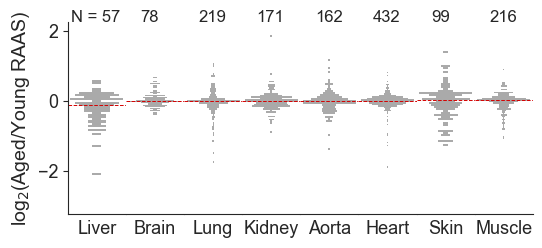

In [ ]:
# plot overall distribution of aged vs young RAAS fold change for each SAAP, per tissue
# pools all (SAAP x aged-timepoint) fold changes within a tissue (mirrors the human per-patient pooling)
# aging_fc_dict = pickle.load(open(OUTDIR+'Aged_v_Young_RAAS_fold_change_data.p','rb'))
fc_dict = aging_fc_dict
fc_tissues = [t for t in datasets if t in fc_dict and not fc_dict[t].empty]

col2plot = 'Log2 Aged/Young RAAS'

sns.set_style('ticks')
fig, axes = plt.subplots(1, len(fc_tissues), figsize=(6, 2.5), sharey=True)

plt.subplots_adjust(wspace=0)
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False, labelbottom=False)
    if ax != axes[0]:
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

# sort tissues in plot by median of distribution
medians = []
for t in fc_tissues:
    data = fc_dict[t][col2plot].values
    data = data[np.isfinite(data)]
    medians.append(np.median(data))
med_sort_idx = list(np.argsort(medians))

for i, t in enumerate(fc_tissues):
    # print(t)
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(t, fontsize=13)
    data = fc_dict[t][col2plot].values
    data = data[np.isfinite(data)]
    bihist(data, data, nbins=70, h=axes[ax_idx])
    if ax_idx == 0:
        axes[ax_idx].annotate('N = '+str(len(data)), (0.05, 1), xycoords='axes fraction', fontsize=12)
    else:
        axes[ax_idx].annotate(str(len(data)), (0.25, 1), xycoords='axes fraction', fontsize=12)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(data), np.median(data)), '--', color='#d40000', linewidth=0.7)
axes[0].set_ylabel('log$_2$(Aged/Young RAAS)', fontsize=14)
axes[0].tick_params('both', labelsize=13)
plt.savefig(PLOT_DIR + 'Aged_v_Young_RAAS_bihist.pdf', bbox_inches='tight')
plt.show()

## 3c Per-SAAP pairwise RAAS significance with age

Per tissue and per **individual SAAP**, test whether log$_{10}$ RAAS at each older age differs from the **6 mo** baseline (6 vs 15, 6 vs 24, 6 vs 30 mo). **Design:** one factor — Age (4 levels), **n = 4 independent mice per group**, no pairing. Cross-sectional: different mice at each age, and a mouse spans *tissues* (not ages), so age groups are independent **within a tissue** and tissues are never pooled.

### Assumptions (diagnostics cells)
Equal-variance parametric tests are justified — both assumptions hold:
- **Normality** — per-SAAP-standardized within-group residuals are ≈ normal (Shapiro *p* ≈ 0.14).
- **Equal variance across ages**, checked two ways:
  - *(A) per-SAAP, within tissue* — the independence-valid check (n ≈ 4/age): Levene (`center='median'`) rejects ≈ 8% of SAAPs ≈ chance → homogeneous in aggregate.
  - *(B) global, mouse as the independent unit* — per-mouse within-group dispersion vs age: ANOVA *p* ≈ 0.52, Levene *p* ≈ 1.0.

  Trust Levene over Bartlett — Bartlett over-rejects on heavy tails at n = 4.

Normal + homoscedastic + a "treatments-vs-one-control" question → **ANOVA + Dunnett (equal variance)** is the best fit; **Student's t-test** is the simpler, directly comparable alternative.

### Tests
| Block | Test | Comparisons |
|---|---|---|
| 3a-i  | **Student's t-test** (equal var) + BH-FDR | each aged vs 6 mo |
| 3a-ii | one-way **ANOVA + Dunnett** (equal var) + BH-FDR | each aged vs 6 mo |

### Toggles (setup cell)
- `STAT_TEST` (`'dunnett'`/`'student'`) — picks the test driving the heatmap/catplot.
- `USE_FDR` — significance metric: raw **p** vs **BH-FDR** across SAAPs, at `SIG_ALPHA`.
- `p_value` = the test's own p (FWER-adjusted within a SAAP for Dunnett); `FDR` = Benjamini–Hochberg across SAAPs within each comparison.

### Assumption Diagnostics

In [56]:
# Per-SAAP pairwise RAAS-vs-age significance: shared setup
# Replicate-level RAAS (one log10 Reporter_RAAS per tissue x SAAP x mouse), helpers, config, and toggles
# shared by the diagnostics / Student t-test / Dunnett blocks and the heatmap + catplot below.
from itertools import combinations

AGE_ORDER    = ['t06mo', 't15mo', 't24mo', 't30mo']
BASELINE_AGE = 't06mo'                                    # young reference ("normal")
AGED_AGES    = [a for a in AGE_ORDER if a != BASELINE_AGE]
MIN_REPS     = 3                                          # min mice/group to test a SAAP in a tissue (of 4)
SIG_ALPHA    = 0.05

# --- toggles ---
USE_FDR      = False        # significance metric: False -> raw p<=SIG_ALPHA ; True -> BH-FDR<=SIG_ALPHA
STAT_TEST    = 'student'    # primary test driving the heatmap/catplot: 'dunnett' or 'student'

def sig_col():   return 'FDR' if USE_FDR else 'p_value'   # column used for significance calls downstream
def sig_label(): return 'FDR' if USE_FDR else 'p'

def run_fdr(df, p_col, out_col='FDR'):
    # Benjamini-Hochberg across rows, preserving NaN p-values
    df = df.copy(); df[out_col] = np.nan
    ok = df[p_col].notna()
    if ok.any():
        df.loc[ok, out_col] = multipletests(df.loc[ok, p_col], method='fdr_bh')[1]
    return df

def fdr_within(df, p_col, group_col, out_col='FDR'):
    # BH-FDR across SAAPs *within* each comparison
    if df.empty:
        return df
    return pd.concat([run_fdr(g, p_col, out_col) for _, g in df.groupby(group_col)], ignore_index=True)

# tidy replicate table: one finite log10 RAAS per (tissue, SAAP, mouse)
raas_rep_df = SAAP_quant_df[['Dataset', *SAAP_KEYS, 'Sample Type', 'Sample', 'Reporter_RAAS']].copy()
raas_rep_df['Reporter_RAAS'] = pd.to_numeric(raas_rep_df['Reporter_RAAS'], errors='coerce')
raas_rep_df = raas_rep_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Reporter_RAAS'])

def iter_saaps(rep=None, age_col='Sample Type'):
    # yield (tissue, saap_key_tuple, {age: RAAS array}, group_df) for each tissue x SAAP
    rep = raas_rep_df if rep is None else rep
    for (tissue, *keys), g in rep.groupby(['Dataset', *SAAP_KEYS], observed=True):
        by_age = {a: v['Reporter_RAAS'].values for a, v in g.groupby(age_col, observed=True)}
        yield tissue, tuple(keys), by_age, g

def sig_summary(df, p_col, label_col):
    # n significant SAAPs (raw p and FDR) per comparison
    for lab, g in df.groupby(label_col):
        print(f"    {lab:18} tested={len(g):4d}  p<={SIG_ALPHA}: {int((g[p_col]<=SIG_ALPHA).sum()):4d}"
              f"  FDR<={SIG_ALPHA}: {int((g['FDR']<=SIG_ALPHA).sum()):4d}")

print(f"{len(raas_rep_df):,} replicate RAAS values across "
      f"{raas_rep_df.groupby(['Dataset',*SAAP_KEYS],observed=True).ngroups:,} tissue x SAAP groups")

7,644 replicate RAAS values across 478 tissue x SAAP groups


In [93]:
# 3c  Assumption diagnostics for the per-SAAP age tests: equal variance + normality across ages.
# Design: each mouse = (rep, age). Ages are DIFFERENT mice (cross-sectional), but a mouse spans every
# tissue -> mice are repeated ACROSS TISSUES, not across ages. So within a tissue the age groups are
# independent (n=4 distinct mice/age) and per-tissue tests are valid; pooling raw RAAS across tissues is
# NOT valid (the same mouse sits in every tissue, and the spread is dominated by SAAP-to-SAAP differences).
# Three checks:
#   (A) PER-SAAP equal variance  -- within each tissue x SAAP across ages (independence-valid); % rejecting H0.
#   (B) GLOBAL  equal variance   -- mouse as the independent unit (the only correct global test).
#   (C) NORMALITY                -- per-SAAP-standardized within-group residuals (assumption behind t/Dunnett & Bartlett).
from scipy.stats import binomtest

# (A) per-SAAP: distribution of variance-test p-values across tissue x SAAP groups (all available ages)
bartlett_p_saap, levene_p_saap = [], []
for tissue, keys, by_age, _ in iter_saaps():
    ages = [a for a in AGE_ORDER if len(by_age.get(a, [])) >= MIN_REPS]
    if len(ages) < 2:
        continue
    arrs = [by_age[a] for a in ages]
    try:
        bartlett_p_saap.append(stats.bartlett(*arrs).pvalue)               # assumes normality
    except Exception:
        pass
    try:
        levene_p_saap.append(stats.levene(*arrs, center='median').pvalue)  # robust to non-normality
    except Exception:
        pass
bp, lp = np.array(bartlett_p_saap), np.array(levene_p_saap)
print(f"--- (A) Per-SAAP equal-variance across ages (% of tested SAAPs rejecting H0 at p<={SIG_ALPHA}) ---")
print(f"  Bartlett (assumes normal) : tested={len(bp):4d}   reject={np.mean(bp<=SIG_ALPHA)*100:5.1f}%")
print(f"  Levene   (robust, median) : tested={len(lp):4d}   reject={np.mean(lp<=SIG_ALPHA)*100:5.1f}%")
_nrej = int((lp <= SIG_ALPHA).sum())
print(f"  Levene reject rate vs {SIG_ALPHA*100:.0f}% chance: one-sided binomial p="
      f"{binomtest(_nrej, len(lp), SIG_ALPHA, alternative='greater').pvalue:.2g}  ({_nrej}/{len(lp)})")
print("  -> trust Levene over Bartlett (Bartlett over-rejects on heavy tails): homogeneous in aggregate,")
print("     with only a small minority of SAAPs deviating.\n")

# (B) GLOBAL equal variance across ages -- mouse as the independent unit.
# Take within-group residuals (remove each tissue x SAAP x age mean = the RAAS landscape), collapse to one
# RMS dispersion per mouse (= rep x age), then test whether dispersion differs across ages (n=4 mice/age).
rep_df = raas_rep_df.copy()
rep_df['rep']   = rep_df['Sample'].str.extract(r'(rep\d+)')[0]
rep_df['resid'] = (rep_df['Reporter_RAAS']
                   - rep_df.groupby(['Dataset', *SAAP_KEYS, 'Sample Type'], observed=True)['Reporter_RAAS'].transform('mean'))
disp = (rep_df.groupby(['rep', 'Sample Type'])['resid']
              .apply(lambda s: np.sqrt((s ** 2).mean()))
              .reset_index(name='rms'))
groups = [disp.loc[disp['Sample Type'] == a, 'rms'].values for a in AGE_ORDER if (disp['Sample Type'] == a).any()]
F, p_anova = stats.f_oneway(*groups)
print("--- (B) GLOBAL within-group RAAS dispersion across ages (per-mouse, n=4/age; the valid unit) ---")
for a in AGE_ORDER:
    v = disp.loc[disp['Sample Type'] == a, 'rms'].values
    if len(v):
        print(f"  {a}: mean within-group RMS = {v.mean():.3f}  (mice: {np.round(v, 3)})")
print(f"  one-way ANOVA across ages: F={F:.2f}, p={p_anova:.3f}   "
      f"Levene(median): p={stats.levene(*groups, center='median').pvalue:.3f}   -> p>0.05 = equal variance\n")

# (C) NORMALITY of within-group RAAS (assumption behind the parametric t/Dunnett tests and Bartlett).
# Per-SAAP-standardized residuals (each SAAP's within-group residuals / its pooled SD) pool onto one scale;
# Shapiro on a capped random subsample (Shapiro over-rejects at very large n).
_std = []
for tissue, keys, by_age, _ in iter_saaps():
    arrs = [by_age[a] for a in AGE_ORDER if len(by_age.get(a, [])) >= MIN_REPS]
    if len(arrs) < 2:
        continue
    res = np.concatenate([v - v.mean() for v in arrs])
    k, N = len(arrs), sum(map(len, arrs))
    mse = (res ** 2).sum() / (N - k)
    if mse > 0:
        _std.extend(res / np.sqrt(mse))
_std = np.array(_std)
_sub = np.random.RandomState(0).choice(_std, min(2000, len(_std)), replace=False)
W, p_shap = stats.shapiro(_sub)
alpha = 0.05
print(f"--- (C) Shapiro-Wilk normality of per-SAAP-standardized within-group residuals (n_sub={len(_sub)}) ---")
print(f"  W= {W:.4f}")
print(f"  p-value= {p_shap:.3g}   (skew={stats.skew(_std):.2f}, excess kurtosis={stats.kurtosis(_std):.2f})")
if p_shap > alpha:
    print("  Fail to reject the null hypothesis (Data looks normally distributed)")
else:
    print("  Reject the null hypothesis (Data does not look normally distributed)")

--- (A) Per-SAAP equal-variance across ages (% of tested SAAPs rejecting H0 at p<=0.05) ---
  Bartlett (assumes normal) : tested= 478   reject=  7.7%
  Levene   (robust, median) : tested= 478   reject=  7.3%
  Levene reject rate vs 5% chance: one-sided binomial p=0.017  (35/478)
  -> trust Levene over Bartlett (Bartlett over-rejects on heavy tails): homogeneous in aggregate,
     with only a small minority of SAAPs deviating.

--- (B) GLOBAL within-group RAAS dispersion across ages (per-mouse, n=4/age; the valid unit) ---
  t06mo: mean within-group RMS = 0.083  (mice: [0.094 0.087 0.069 0.081])
  t15mo: mean within-group RMS = 0.087  (mice: [0.067 0.108 0.086 0.086])
  t24mo: mean within-group RMS = 0.084  (mice: [0.073 0.07  0.085 0.109])
  t30mo: mean within-group RMS = 0.080  (mice: [0.072 0.075 0.089 0.084])
  one-way ANOVA across ages: F=0.16, p=0.920   Levene(median): p=0.779   -> p>0.05 = equal variance

--- (C) Shapiro-Wilk normality of per-SAAP-standardized within-group residu

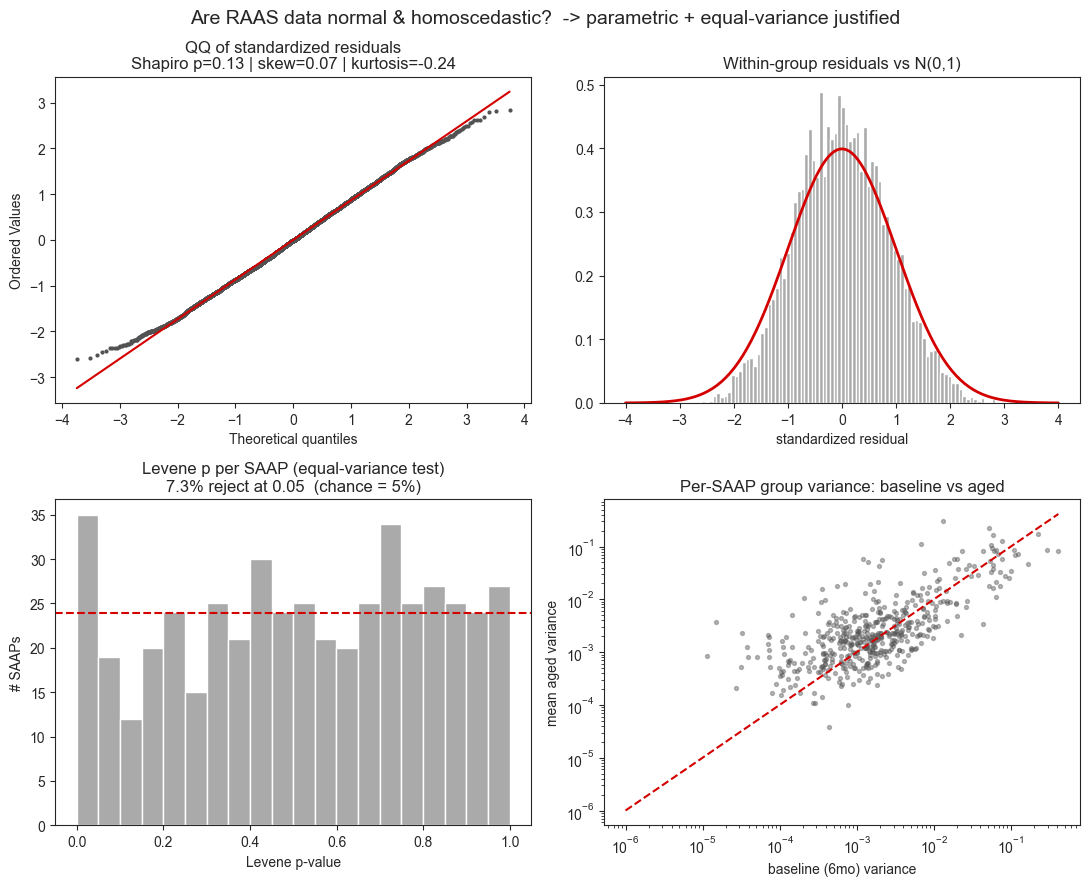

normality: Shapiro p=0.13, skew=0.07, excess kurtosis=-0.24
equal variance: Levene rejects 7.3% of 478 SAAPs (chance 5%)


In [94]:
# Diagnostics plot (reuses 3c -- does NOT recompute). Same residuals, Levene p-values and Shapiro
# result as cell 3c above:  sr = _std (per-SAAP-standardized within-group residuals),
# lev = lp (per-SAAP Levene p across ages), normality p = p_shap (Shapiro, 5000-cap subsample).
# Only the baseline(6mo)-vs-aged per-SAAP variances are plot-specific, so compute just those here.
base_var, aged_var = [], []
for tissue, keys, by_age, _ in iter_saaps():
    ages = [a for a in AGE_ORDER if len(by_age.get(a, [])) >= MIN_REPS]
    if len(ages) < 2:
        continue
    if 't06mo' in by_age and len(by_age['t06mo']) >= MIN_REPS:
        base_var.append(np.var(by_age['t06mo'], ddof=1))
        aged_var.append(np.mean([np.var(by_age[a], ddof=1) for a in ages if a != 't06mo']))

sr, lev = _std, lp                                       # reuse 3c's residuals and Levene p-values

fig, ax = plt.subplots(2, 2, figsize=(11, 9))
stats.probplot(sr, dist='norm', plot=ax[0, 0])
ax[0, 0].get_lines()[0].set(color='#525252', ms=2); ax[0, 0].get_lines()[1].set(color='#d40000')
ax[0, 0].set_title(f'QQ of standardized residuals\nShapiro p={p_shap:.2g} | skew={stats.skew(sr):.2f} | kurtosis={stats.kurtosis(sr):.2f}')
xs = np.linspace(-4, 4, 200)
ax[0, 1].hist(sr, bins=80, density=True, color='#aaaaaa')
ax[0, 1].plot(xs, stats.norm.pdf(xs), color='#d40000', lw=2)
ax[0, 1].set_title('Within-group residuals vs N(0,1)'); ax[0, 1].set_xlabel('standardized residual')
ax[1, 0].hist(lev, bins=20, color='#aaaaaa', edgecolor='w')
ax[1, 0].axhline(len(lev) / 20, color='#d40000', ls='--')
ax[1, 0].set_title(f'Levene p per SAAP (equal-variance test)\n{(lev<=0.05).mean()*100:.1f}% reject at 0.05  (chance = 5%)')
ax[1, 0].set_xlabel('Levene p-value'); ax[1, 0].set_ylabel('# SAAPs')
mx = max(max(base_var), max(aged_var))
ax[1, 1].scatter(base_var, aged_var, s=8, color='#525252', alpha=.4)
ax[1, 1].plot([1e-6, mx], [1e-6, mx], color='#d40000', ls='--')
ax[1, 1].set(xscale='log', yscale='log', xlabel='baseline (6mo) variance', ylabel='mean aged variance',
             title='Per-SAAP group variance: baseline vs aged')
fig.suptitle('Are RAAS data normal & homoscedastic?  -> parametric + equal-variance justified', fontsize=14)
fig.tight_layout()
plt.savefig(PLOT_DIR + 'Aging_RAAS_test_diagnostics.pdf', bbox_inches='tight')
plt.show()
print(f"normality: Shapiro p={p_shap:.2g}, skew={stats.skew(sr):.2f}, excess kurtosis={stats.kurtosis(sr):.2f}")
print(f"equal variance: Levene rejects {(lev<=0.05).mean()*100:.1f}% of {len(lev)} SAAPs (chance 5%)")

### Statistical Testing

In [66]:
# 3a-i  Pairwise Student's t-test (equal variance) of log10 RAAS, each aged age vs 6mo baseline + BH-FDR across SAAPs
# Equal-variance t-test is justified by the diagnostics above (residuals ~normal; Levene rejects equal
# variance for only ~8% of SAAPs ~ chance). At balanced n=4 the equal-variance pooling recovers df/power.
# rep=None -> per-tissue (groups by Dataset x SAAP); pass a pooled rep (one Dataset) for an AllTissues cohort.
def pairwise_ttest_vs_baseline(equal_var=True, rep=None):
    rows = []
    for tissue, keys, by_age, _ in iter_saaps(rep):
        base = by_age.get(BASELINE_AGE, np.empty(0))
        if len(base) < MIN_REPS:
            continue
        for a in AGED_AGES:
            cur = by_age.get(a, np.empty(0))
            if len(cur) < MIN_REPS:
                continue
            stat, p = ttest_ind(cur, base, equal_var=equal_var)
            rows.append({'Dataset': tissue, **dict(zip(SAAP_KEYS, keys)),
                         'comparison': f'{a} vs {BASELINE_AGE}',
                         'mean_log2FC': (cur.mean() - base.mean()) * np.log2(10),
                         't_stat': stat, 'p_value': p, 'n_aged': len(cur), 'n_base': len(base)})
    return fdr_within(pd.DataFrame(rows), 'p_value', 'comparison')

aging_ttest_student = pairwise_ttest_vs_baseline(equal_var=True)
pickle.dump(aging_ttest_student, open(OUTDIR + 'Aging_RAAS_pairwise_ttest_Student.p', 'wb'))
print("Student's t-test (equal variance), each aged age vs 6mo:")
sig_summary(aging_ttest_student, 'p_value', 'comparison')

Student's t-test (equal variance), each aged age vs 6mo:
    t15mo vs t06mo     tested= 478  p<=0.05:   54  FDR<=0.05:    0
    t24mo vs t06mo     tested= 478  p<=0.05:   70  FDR<=0.05:   12
    t30mo vs t06mo     tested= 478  p<=0.05:   89  FDR<=0.05:   11


In [67]:
# 3a-ii  One-way ANOVA + Dunnett's test (each aged age vs 6mo control; equal variance) + BH-FDR across SAAPs
# Dunnett's p is family-wise-error adjusted across the aged-vs-control comparisons *within* each SAAP;
# FDR then controls multiplicity across SAAPs. (scipy.stats.dunnett is equal-variance only.)
# rep=None -> per-tissue; pass a pooled rep (one Dataset) for an AllTissues cohort.
def dunnett_vs_baseline(rep=None):
    rows = []
    for tissue, keys, by_age, _ in iter_saaps(rep):
        base = by_age.get(BASELINE_AGE, np.empty(0))
        if len(base) < MIN_REPS:
            continue
        aged = [a for a in AGED_AGES if len(by_age.get(a, [])) >= MIN_REPS]
        if not aged:
            continue
        res = stats.dunnett(*[by_age[a] for a in aged], control=base)
        for a, st, p in zip(aged, np.atleast_1d(res.statistic), np.atleast_1d(res.pvalue)):
            rows.append({'Dataset': tissue, **dict(zip(SAAP_KEYS, keys)),
                         'comparison': f'{a} vs {BASELINE_AGE}',
                         'mean_log2FC': (by_age[a].mean() - base.mean()) * np.log2(10),
                         'dunnett_stat': st, 'p_value': p, 'n_aged': len(by_age[a]), 'n_base': len(base)})
    return fdr_within(pd.DataFrame(rows), 'p_value', 'comparison')

aging_dunnett = dunnett_vs_baseline()
pickle.dump(aging_dunnett, open(OUTDIR + 'Aging_RAAS_ANOVA_Dunnett.p', 'wb'))
print("ANOVA + Dunnett (each aged age vs 6mo control):")
sig_summary(aging_dunnett, 'p_value', 'comparison')

ANOVA + Dunnett (each aged age vs 6mo control):
    t15mo vs t06mo     tested= 478  p<=0.05:   25  FDR<=0.05:    2
    t24mo vs t06mo     tested= 478  p<=0.05:   57  FDR<=0.05:    7
    t30mo vs t06mo     tested= 478  p<=0.05:   64  FDR<=0.05:   29


In [68]:
# 3b  Pick the primary test for the figures below and weigh Student vs Dunnett against each other.
# Diagnostics show log RAAS is ~normal with homogeneous variance, and the question is "each aged age vs the
# 6mo control" -> Dunnett (equal-var, family-wise-error controlled within each SAAP) is the better fit;
# Student's t is the more familiar, directly comparable alternative. Flip STAT_TEST / USE_FDR in the setup cell.
_aging_tests = {'student': aging_ttest_student, 'dunnett': aging_dunnett}
aging_stat_df = _aging_tests[STAT_TEST]
_sc = sig_col()

def _sig_keys(df):
    return set(map(tuple, df.loc[df[_sc] <= SIG_ALPHA, ['Dataset', *SAAP_KEYS, 'comparison']].values))

_s, _d = _sig_keys(aging_ttest_student), _sig_keys(aging_dunnett)
print(f"Primary test = {STAT_TEST.upper()}   |   significance metric = {sig_label()} <= {SIG_ALPHA}\n")
print(f"  Student significant : {len(_s)}")
print(f"  Dunnett significant : {len(_d)}")
print(f"  agree (both)        : {len(_s & _d)}")
print(f"  Student-only        : {len(_s - _d)}   (t-test calls these; Dunnett's within-SAAP FWER does not)")
print(f"  Dunnett-only        : {len(_d - _s)}")

# Per-SAAP p-values for the primary test, 4 sig figs in scientific notation (display only -- the stored
# p_value/FDR columns of aging_stat_df stay numeric for the figures above).
def fmt_pvals(df, cols=('p_value', 'FDR'), digits=3):
    out = df.copy()
    for c in cols:
        if c in out:
            out[c] = out[c].map(lambda v: f'{v:.{digits}e}' if pd.notna(v) else '')
    if 'mean_log2FC' in out:
        out['mean_log2FC'] = out['mean_log2FC'].map(lambda v: f'{v:+.3f}')
    return out

_show = ['Dataset', 'MTP_seq', 'aa_sub', 'comparison', 'mean_log2FC', 'p_value', 'FDR']
print(f"\n{STAT_TEST} p-values (4 sig figs), most significant first:")
print(fmt_pvals(aging_stat_df.sort_values('p_value'))[_show].head(20).to_string(index=False))

Primary test = STUDENT   |   significance metric = p <= 0.05

  Student significant : 213
  Dunnett significant : 146
  agree (both)        : 135
  Student-only        : 78   (t-test calls these; Dunnett's within-SAAP FWER does not)
  Dunnett-only        : 11

student p-values (4 sig figs), most significant first:
Dataset          MTP_seq   aa_sub     comparison mean_log2FC   p_value       FDR
 Muscle    STDAEADVASLNR   A to S t30mo vs t06mo      +0.343 6.366e-06 3.043e-03
   Skin      QLEEAEEESQR   A to S t30mo vs t06mo      +0.822 2.163e-05 5.170e-03
   Skin  NAYEESLDELETLKR   H to E t30mo vs t06mo      -1.151 4.352e-05 6.934e-03
 Muscle    SMTDVLSATDIKK   E to T t24mo vs t06mo      +0.520 6.044e-05 2.273e-02
  Liver       LILPGLMSSR   I to M t30mo vs t06mo      -2.073 6.220e-05 7.433e-03
 Muscle        LNEIVDLIK Q to I/L t24mo vs t06mo      -0.796 1.163e-04 2.273e-02
 Muscle         TAESAEAK   P to A t24mo vs t06mo      -0.231 1.427e-04 2.273e-02
 Muscle    NLLAAGDKDGDGK   T to N t3

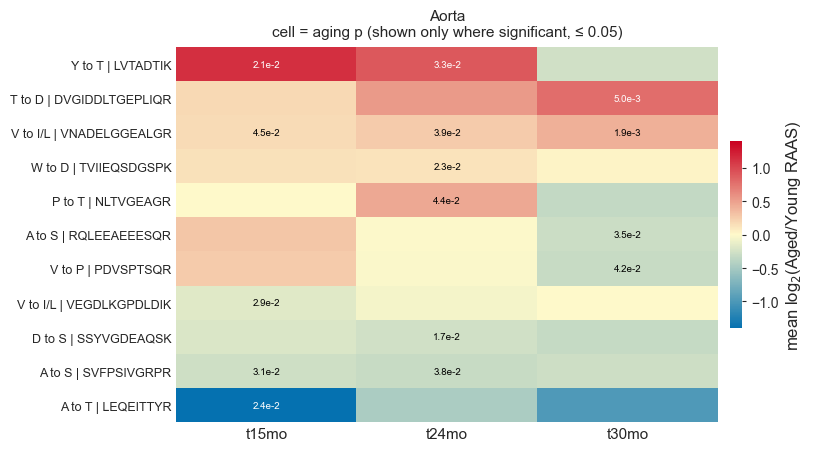

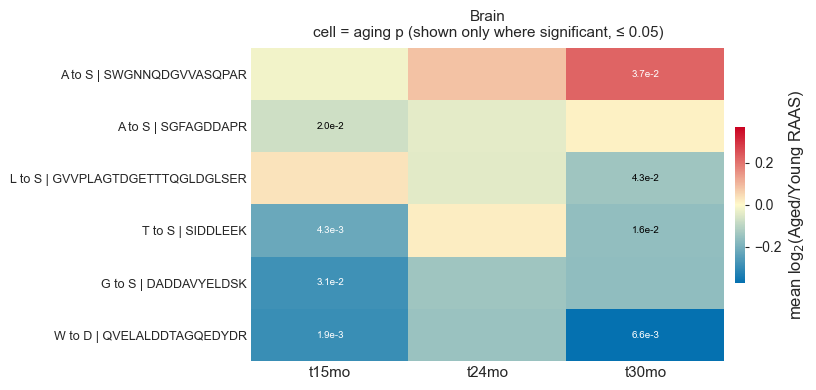

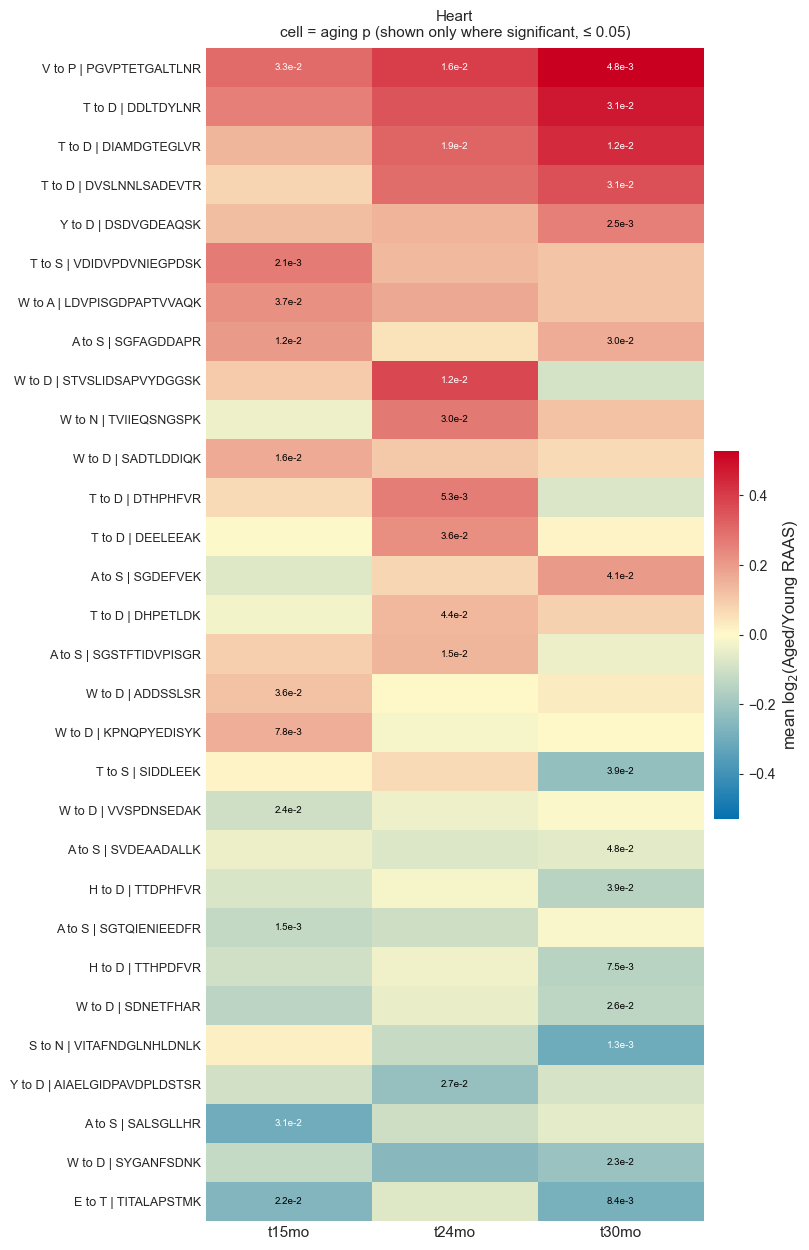

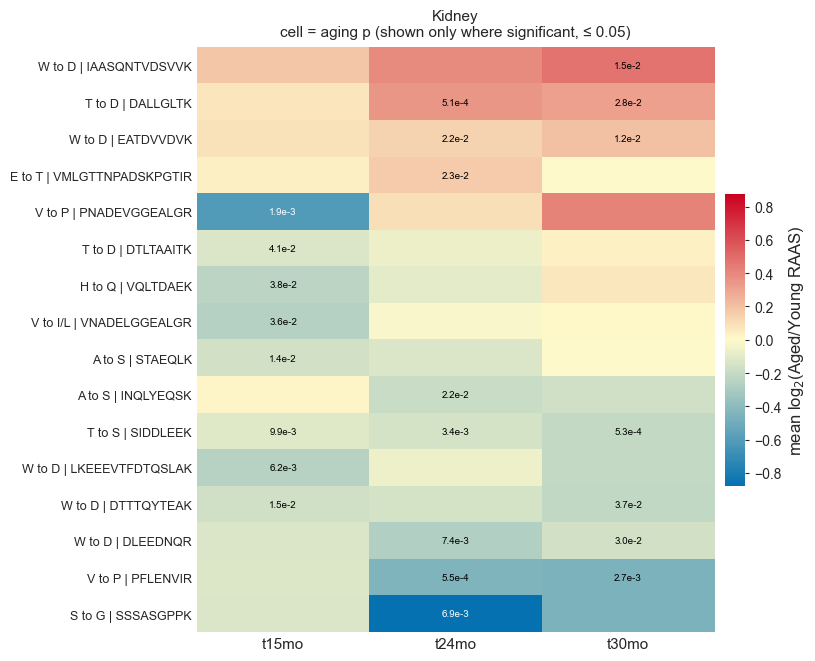

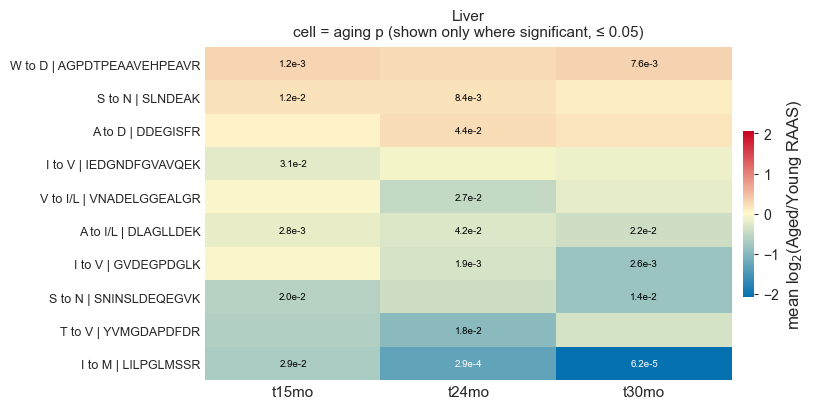

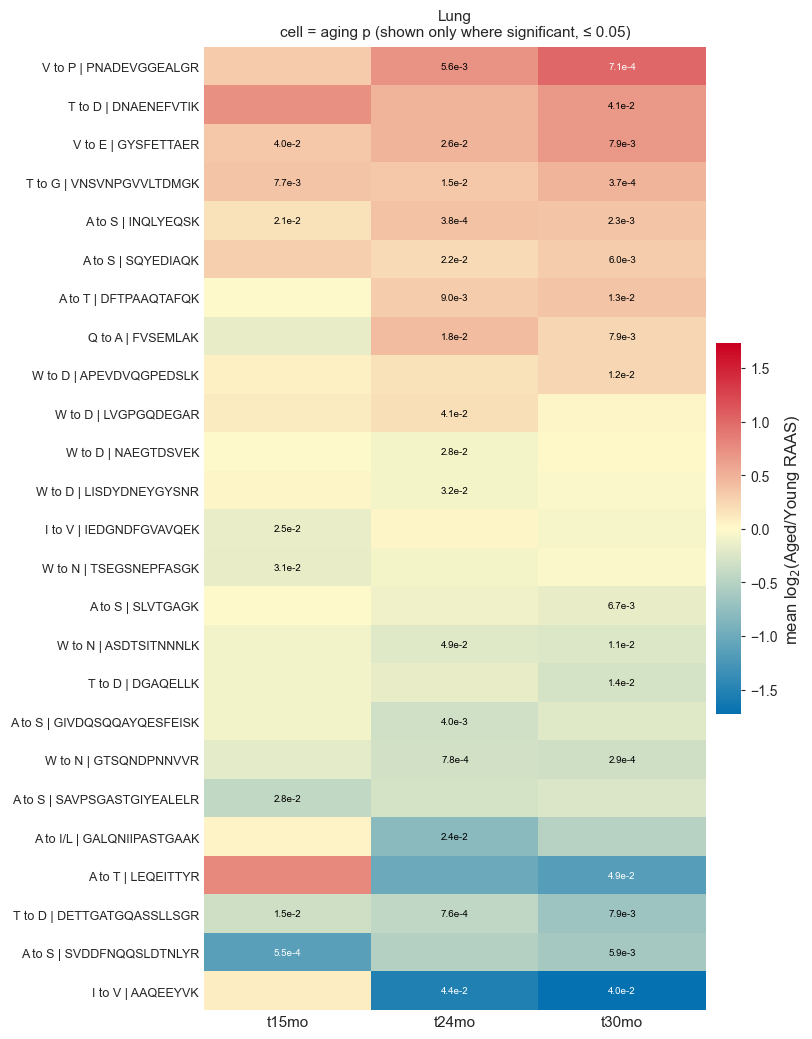

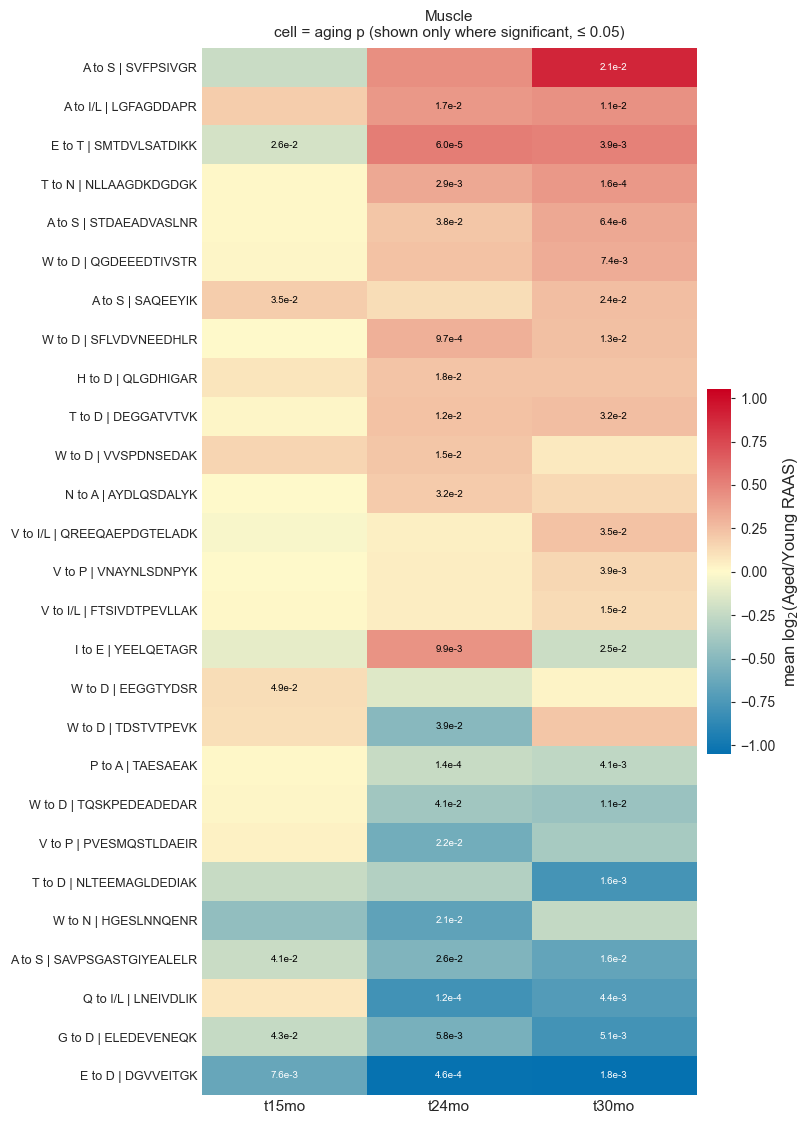

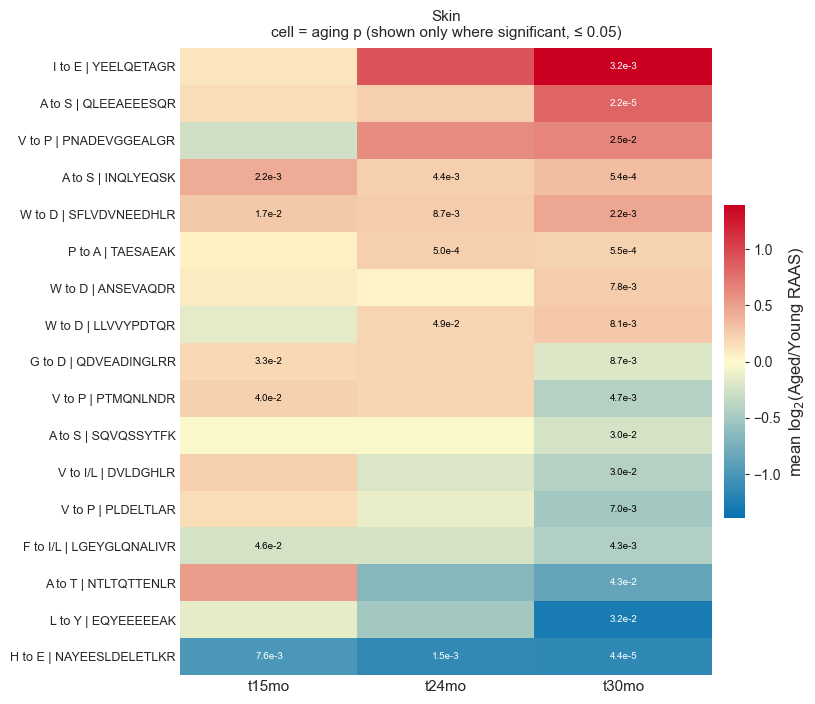

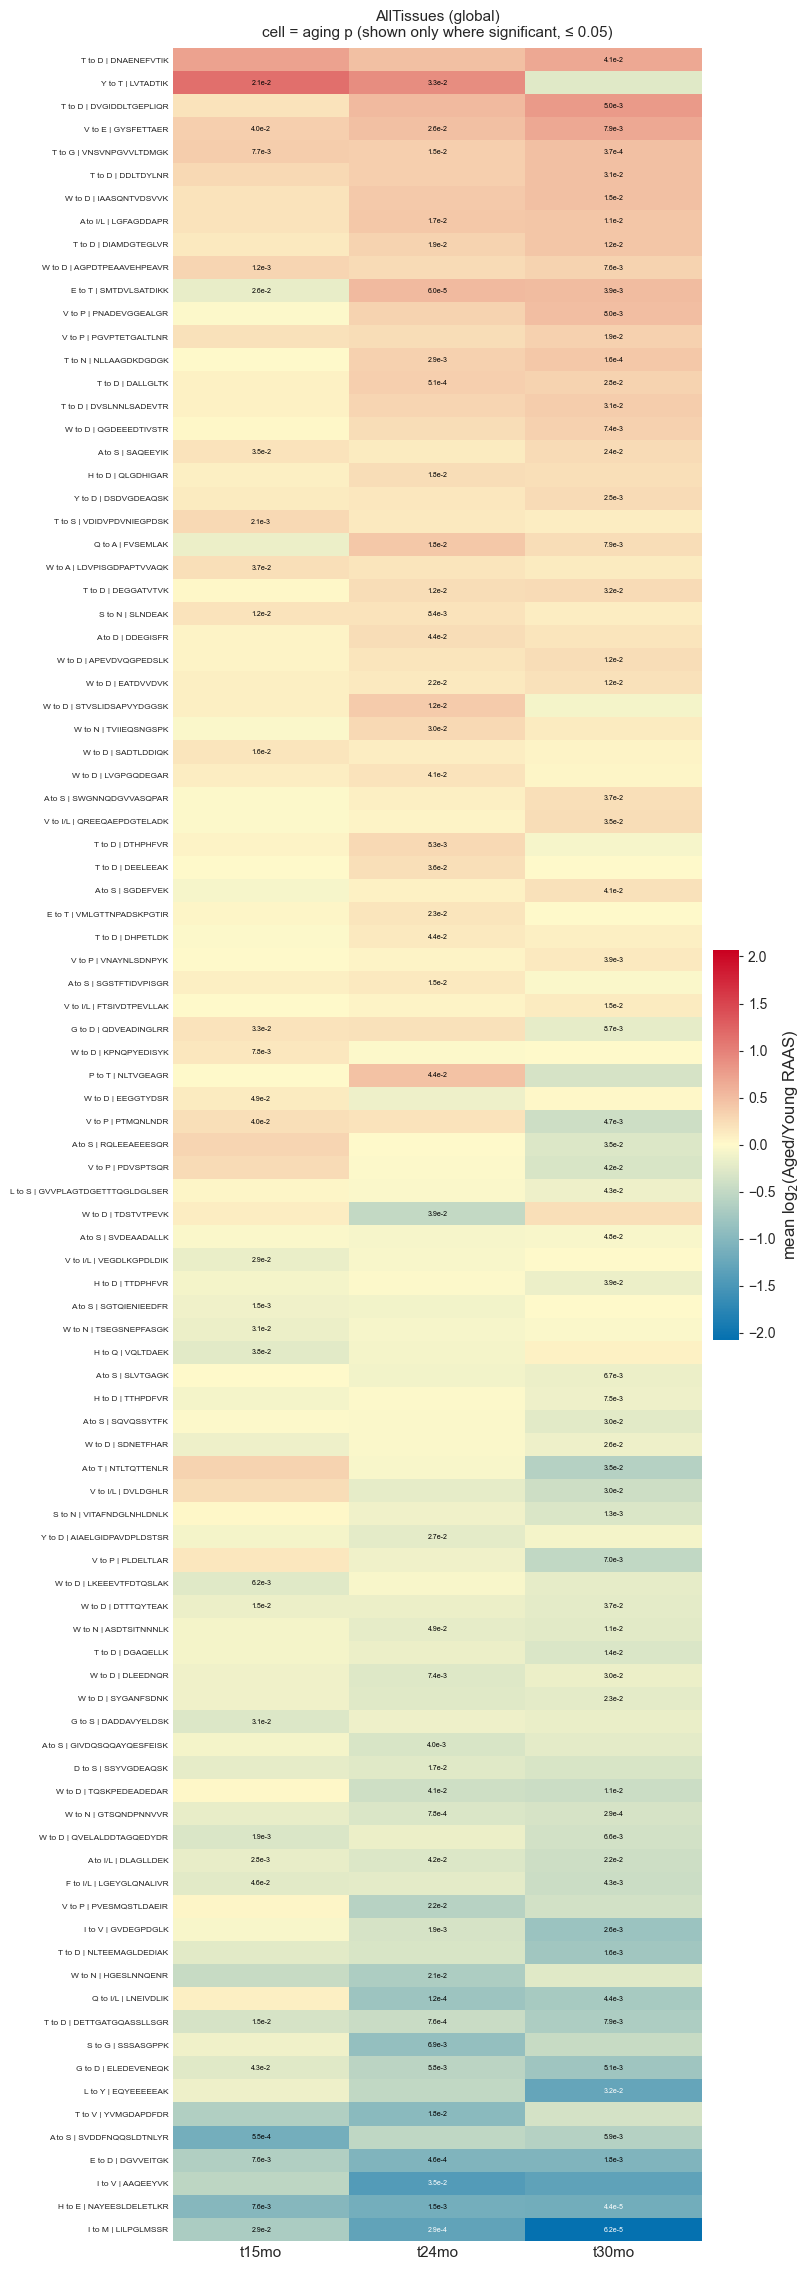

In [69]:
# 3d  Per-SAAP RAAS-fold-change-with-aging heatmaps, styled after Alex_Analysis_Mouse_Pipeline.ipynb
# plot_sig_heatmap: one heatmap per tissue + a pooled 'AllTissues'. Rows = SAAPs significant by the primary
# test in >=1 aged comparison (sig_label() <= SIG_ALPHA), sorted high->low by mean older-age log2FC; columns =
# aged timepoints; color = mean log2(Aged/Young RAAS); cell text = THAT SAAP's aging significance, shown ONLY
# in cells where the change is significant (sig_col() <= SIG_ALPHA).
from matplotlib.colors import LinearSegmentedColormap
RAAS_div = LinearSegmentedColormap.from_list('RAAS_div', ['#0571b0', '#fffacb', '#ca0020'])   # Mouse_Pipeline palette
aged_cols = [a for a in AGE_ORDER if a != BASELINE_AGE]

def _fmt_p(p):   # compact scientific p-value, e.g. 1.2e-5 (no leading zeros in exponent)
    s = f'{p:.1e}'
    mant, exp = s.split('e')
    return f'{mant}e{int(exp)}'

def _cohort_fc_p(stat_df, fc_df):
    # per-SAAP fold-change matrix + matching significance matrix (rows = significant SAAPs, cols = aged ages)
    sig_keys = set(map(tuple, stat_df.loc[stat_df[sig_col()] <= SIG_ALPHA, SAAP_KEYS].values))
    if not sig_keys:
        return None, None
    lab = lambda k: f"{k[2]} | {k[0]}"
    fc_rows = {lab(keys): g.groupby('Age group')['Log2 Aged/Young RAAS'].mean().reindex(aged_cols)
               for keys, g in fc_df.groupby(SAAP_KEYS, observed=True) if tuple(keys) in sig_keys}
    if not fc_rows:
        return None, None
    fc_mat = pd.DataFrame(fc_rows).T.reindex(columns=aged_cols)
    fc_mat = fc_mat.reindex(fc_mat.mean(axis=1).sort_values(ascending=False).index)
    p_rows = {lab(keys): {tp: g.set_index('comparison')[sig_col()].get(f'{tp} vs {BASELINE_AGE}', np.nan)
                          for tp in aged_cols}
              for keys, g in stat_df.groupby(SAAP_KEYS, observed=True) if tuple(keys) in sig_keys}
    p_mat = pd.DataFrame(p_rows).T.reindex(index=fc_mat.index, columns=aged_cols)
    return fc_mat, p_mat

def plot_saap_aging_heatmap(fc_mat, p_mat, title, fname):
    if fc_mat is None or fc_mat.empty:
        print(f'[{title}] no SAAPs pass {sig_label()} <= {SIG_ALPHA}; no heatmap.'); return
    n_rows, n_cols = fc_mat.shape
    vmax = np.nanmax(np.abs(fc_mat.values))
    row_h = 0.42 if n_rows < 40 else (0.24 if n_rows < 120 else 0.13)
    yfs = 9 if n_rows < 40 else (6 if n_rows < 120 else 4)
    afs = 7 if n_rows < 40 else (5 if n_rows < 120 else 3)
    fig, ax = plt.subplots(figsize=(2.5 + n_cols * 1.9, max(4, n_rows * row_h)))
    im = ax.imshow(fc_mat, aspect='auto', cmap=RAAS_div, vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(n_cols)); ax.set_xticklabels(aged_cols, fontsize=11)
    ax.set_yticks(range(n_rows)); ax.set_yticklabels(fc_mat.index, fontsize=yfs)
    ax.tick_params(length=0)
    for sp in ax.spines.values():
        sp.set_visible(False)
    for i in range(n_rows):
        for j in range(n_cols):
            p, fc = p_mat.iat[i, j], fc_mat.iat[i, j]
            if np.isfinite(p) and p <= SIG_ALPHA:   # annotate only significant cells
                ax.text(j, i, _fmt_p(p), ha='center', va='center', fontsize=afs,
                        color='w' if (np.isfinite(fc) and abs(fc) > 0.55 * vmax) else 'k')
    ax.set_title(f'{title}\ncell = aging {sig_label()} (shown only where significant, ≤ {SIG_ALPHA})',
                 fontsize=11, pad=8)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, shrink=0.5, aspect=15)
    cbar.set_label('mean log$_2$(Aged/Young RAAS)', fontsize=12)
    cbar.ax.tick_params(length=3, labelsize=10); cbar.outline.set_visible(False)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}{fname}.pdf', bbox_inches='tight')
    plt.show()

# per-tissue heatmaps
for tissue in [t for t in datasets if t in aging_fc_dict and not aging_fc_dict[t].empty]:
    fc_mat, p_mat = _cohort_fc_p(aging_stat_df[aging_stat_df['Dataset'] == tissue], aging_fc_dict[tissue])
    plot_saap_aging_heatmap(fc_mat, p_mat, tissue, f'Aging_RAAS_SAAP_heatmap_{tissue}')

# pooled 'AllTissues' cohort: recompute the chosen test on SAAP observations pooled across organs
_pooled_rep = raas_rep_df.assign(Dataset='AllTissues')
pooled_stat = (dunnett_vs_baseline(rep=_pooled_rep) if STAT_TEST == 'dunnett'
               else pairwise_ttest_vs_baseline(rep=_pooled_rep))
_all_fc = pd.concat([d for d in aging_fc_dict.values() if not d.empty], ignore_index=True)
fc_mat, p_mat = _cohort_fc_p(pooled_stat, _all_fc)
plot_saap_aging_heatmap(fc_mat, p_mat, 'AllTissues (global)', 'Aging_RAAS_SAAP_heatmap_AllTissues')

## 3d Relative RAAS computed for shared SAAP between 2 mouse samples

In [72]:
# Create a matrix with median  of relative RAAS computed for shared peptides between each pair of patients. Or read in below

all_ds_matrices = {}
ds_report_df = SAAP_quant_df
ds_report_df.sort_values('Reporter_RAAS', inplace=True)
set_samples = list(set(ds_report_df['Sample'].values))
ds_matrix_rowcol = pd.DataFrame(index=set_samples, columns=set_samples)

for sample1 in set_samples:
    sample1_df = ds_report_df.loc[ds_report_df['Sample']==sample1]
    sample1_saap_bp = [sample1_df['MTP_seq'].to_list()[i]+':'+sample1_df['BP_seq'].to_list()[i] for i in range(len(sample1_df))]

    other_samples = set_samples[set_samples.index(sample1):]
    for sample2 in other_samples:
        sample2_df = ds_report_df.loc[ds_report_df['Sample']==sample2]
        sample2_saap_bp = [sample2_df['MTP_seq'].to_list()[i]+':'+sample2_df['BP_seq'].to_list()[i] for i in range(len(sample2_df))]
        shared_saap_bp = [x for x in sample1_saap_bp if x in sample2_saap_bp]
        row_shared_raas_ratios = []
        col_shared_raas_ratios = []
        
        # for each SAAP shared between 2 patients, compute relative RAAS on log2 scale
        for sb, saap_bp in enumerate(shared_saap_bp):
            saap = saap_bp.split(':')[0]
            bp = saap_bp.split(':')[1]
            raas1 = sample1_df.loc[(sample1_df['MTP_seq']==saap) & (sample1_df['BP_seq']==bp), 'Reporter_RAAS'].values[0]
            raas2 = sample2_df.loc[(sample2_df['MTP_seq']==saap) & (sample2_df['BP_seq']==bp), 'Reporter_RAAS'].values[0]
            if ~np.isnan(raas1) and ~np.isnan(raas2) and ~np.isinf(raas1) and ~np.isinf(raas2):
                raas_ratio = raas1 - raas2
                raas_ratio = np.log2(10**raas_ratio)
                col_raas_ratio = raas2 - raas1
                col_raas_ratio = np.log2(10**col_raas_ratio)
                row_shared_raas_ratios.append(raas_ratio)
                col_shared_raas_ratios.append(col_raas_ratio)
        ds_matrix_rowcol.loc[sample1, sample2] = np.nanmedian(row_shared_raas_ratios)
        ds_matrix_rowcol.loc[sample2, sample1] = np.nanmedian(col_shared_raas_ratios)

all_ds_matrices['All_data'] = {'Row_col':ds_matrix_rowcol}

# Add N SAAP per comparison to all_data matrix
ds_report_df = SAAP_quant_df
ds_report_df.sort_values('Reporter_RAAS', inplace=True)
set_samples = list(set(ds_report_df['Sample'].values))

ds_matrix_rowcol = pd.DataFrame(index=set_samples, columns=set_samples)
for i,sample1 in enumerate(set_samples):
    if i%100==0:
        print(i)
    sample1_df = ds_report_df.loc[ds_report_df['Sample']==sample1]
    sample1_saap_bp = [sample1_df['MTP_seq'].to_list()[i]+':'+sample1_df['BP_seq'].to_list()[i] for i in range(len(sample1_df))]
    other_samples = set_samples[set_samples.index(sample1):]
    for sample2 in other_samples:
        sample2_df = ds_report_df.loc[ds_report_df['Sample']==sample2]
        sample2_saap_bp = [sample2_df['MTP_seq'].to_list()[i]+':'+sample2_df['BP_seq'].to_list()[i] for i in range(len(sample2_df))]
        shared_saap_bp = [x for x in sample1_saap_bp if x in sample2_saap_bp]
        ds_matrix_rowcol.loc[sample1, sample2] = len(shared_saap_bp)
        ds_matrix_rowcol.loc[sample2, sample1] = len(shared_saap_bp)

all_ds_matrices['All_data']['N_shared_saap'] = ds_matrix_rowcol

pickle.dump(all_ds_matrices, open(OUTDIR+'All_pairwise_sample_RAAS_ratio_matrices_log2.p', 'wb'))

0
100


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_16693/1402651026.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Median log$_{10}$(RAAS) ratio', y='Index', palette='RdBu_r', saturation=1,linewidth=0)


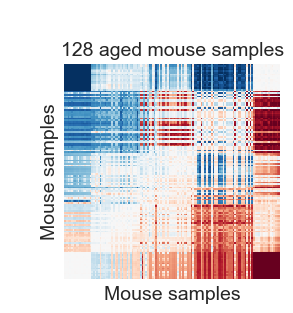

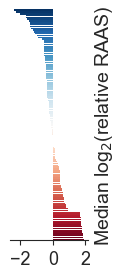

In [73]:
# plot heatmap sorted by row/col median 
ds = 'All_data'

ds_matrix = all_ds_matrices[ds]['Row_col'].astype(float)
medians = [np.median([x for x in row.values if ~np.isnan(x)]) for i,row in ds_matrix.iterrows()]
srt_idx = np.argsort(medians)
col_medians = [np.median([x for x in ds_matrix[col].to_list() if ~np.isnan(x)]) for col in ds_matrix.columns]
col_srt_idx = np.argsort(col_medians)
plot_matrix = ds_matrix.iloc[srt_idx, col_srt_idx]


c = sns.clustermap(plot_matrix, row_cluster=False, col_cluster=False, cmap='RdBu_r', center=0, robust=True, 
                   yticklabels=False, xticklabels=False, figsize=(3,3))#, cbar_kws={'ticklocation':'left'})
c.ax_cbar.set_visible(False)
c.ax_heatmap.set_xlabel('Mouse samples', fontsize=14)
c.ax_heatmap.set_ylabel('Mouse samples', fontsize=14)
c.ax_heatmap.yaxis.set_label_position('left')
c.ax_heatmap.set_title('128 aged mouse samples', fontsize=14)

c.savefig(OUTDIR+ds+'_Paired_RAAS_ratios_btwn_samples_median_sorted_rowcol_log2_nocbar.pdf', bbox_inches='tight')

medians = [np.median([x for x in row.values if ~np.isnan(x)]) for i,row in plot_matrix.iterrows()]

# barplot of patient medians
srt_medians = [medians[i] for i in srt_idx]
str_srt_idx = [str(x) for x in srt_idx]
plot_df = pd.DataFrame(zip(str_srt_idx, srt_medians), columns=['Index','Median log$_{10}$(RAAS) ratio'])
plot_df.sort_values('Median log$_{10}$(RAAS) ratio', inplace=True)

sns.set_style('ticks')
fig,ax = plt.subplots(figsize=(1,3))
sns.barplot(data=plot_df, x='Median log$_{10}$(RAAS) ratio', y='Index', palette='RdBu_r', saturation=1,linewidth=0)
ax.set_ylabel(None)
ax.set_yticks([]);
ax.tick_params('x', labelsize=13)
plt.ylabel('Median log$_{2}$(relative RAAS)', fontsize=14)
plt.xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([-2,0,2]);
ax.yaxis.set_label_position('right')

plt.savefig(PLOT_DIR+'_Paired_RAAS_ratios_btwn_samples_median_barplot_log2.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'_Paired_RAAS_ratios_btwn_samples_median_barplot_log2.png',dpi=600, bbox_inches='tight')

In [74]:
# Weighted means of relative RAAS for each patient in each dataset

# Function to calculate weighted mean 
def weighted_mean(vals, ns):
    """ function to get mean weighted by the number of shared SAAP """
    m = (~np.isnan(vals)) & (~np.isnan(ns)) & (ns > 0)
    if np.sum(m) == 0:
        return(np.nan)
    wmean = np.sum(vals[m]*ns[m])/np.sum(ns[m])
    return(wmean)

all_ds_matrices = pickle.load(open(OUTDIR+'All_Pairwise_sample_RAAS_ratio_matrices_log2.p', 'rb'))
all_ds_matrix = all_ds_matrices['Row_col'].astype(float)
all_ds_n_matrix = all_ds_matrices['N_shared_saap'].astype(float)

unit_dataset = all_ds_matrices['unit_dataset']

plot_datasets = datasets[:-1]
sns.set_style('whitegrid')
fig,axes = plt.subplots(1, len(plot_datasets), figsize=(0.75*len(plot_datasets),3), sharey=True)
plt.subplots_adjust(wspace=0)

# get medians for sorting datasets in plot
medians = []
for i,ds in enumerate(datasets[:-1]):
    ds_samples = unit_dataset[unit_dataset == ds].index.to_list()
    ds_matrix = all_ds_matrix.loc[ds_samples]
    n_matrix = all_ds_n_matrix.loc[ds_samples]
    weighted_means = [weighted_mean(ds_matrix.loc[r], row) for r,row in n_matrix.iterrows()]
    vals = [x for x in weighted_means if ~np.isnan(x)]
    medians.append(np.median(vals))
srt_idx = np.argsort(medians)
ds_sorted = [datasets[:-1][i] for i in srt_idx]

# plot weighted means 
for i,ds in enumerate(ds_sorted):
    ax = axes[i]
    ds_samples = unit_dataset[unit_dataset == ds].index.to_list()
    ds_matrix = all_ds_matrix.loc[ds_samples]
    n_matrix = all_ds_n_matrix.loc[ds_samples]
    
    weighted_means = [weighted_mean(ds_matrix.loc[r], row) for r,row in n_matrix.iterrows()]
    vals = weighted_means
    srt_idx = np.argsort(vals)
    srt_vals = [vals[s] for s in srt_idx]
    plot_df = pd.DataFrame(zip(list(range(len(vals))), srt_vals), columns=['Rank', 'RAAS ratio'])

    sns.scatterplot(data=plot_df, y='RAAS ratio', x='Rank', ax=ax, linewidth=0, s=15, color='#aaaaaa')
    ax.set_xlabel(ds, fontsize=12)
    ax.set_xticks([])
    n = len(srt_vals)
    if i == 0:
        ax.annotate('N = '+str(int(np.round(n, 0))), xy=(0.8,1.04), xycoords='axes fraction', ha='right', fontsize=11)
    else:
        ax.annotate(str(int(np.round(n, 0))), xy=(0.5,1.04), xycoords='axes fraction', ha='center', fontsize=11)
    median = np.median([x for x in vals if ~np.isnan(x)])
    ax.plot(ax.get_xlim(), (median,median), color='#d40000', linestyle='--', linewidth=2)
    
axes[0].set_yticks([-1, -0.5, 0, 0.5, 1])
axes[0].tick_params('y', labelsize=13)
axes[0].set_ylabel('log$_{2}$(relative RAAS)', fontsize=14, labelpad=-0.5)

plt.savefig(PLOT_DIR+'All_Paired_RAAS_ratios_btwn_samples_ranksort_allVals_log2_ds_numerator_allotherds_denom_weighted_mean.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR+'All_Paired_RAAS_ratios_btwn_samples_ranksort_allVals_log2_ds_numerator_allotherds_denom_weighted_mean.png',dpi=600, bbox_inches='tight')

KeyError: 'Row_col'